In [1]:
!pip install -q transformers accelerate bitsandbytes
!pip install -q rouge-score bert-score sentence-transformers
!pip install -q gensim rank-bm25 wordcloud seaborn scipy
!pip install -q xgboost lightgbm catboost
!pip install -q google-generativeai openai anthropic
!wget -q https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip -O glove.6B.zip && unzip -o -q glove.6B.zip
print("All dependencies installed ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 929.8/929.8 kB 30.2 MB/s eta 0:00:00
All dependencies installed ✓


In [2]:
import os, re, gc, time, json, warnings, random
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from scipy import stats
from scipy.stats import kruskal
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
warnings.filterwarnings('ignore')
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import nltk
for p in ['stopwords','punkt','wordnet']:
    nltk.download(p, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer as KTok
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, LSTM, GRU, Bidirectional, Conv1D,
    GlobalMaxPooling1D, MaxPooling1D, Dense, Dropout,
    Input, MultiHeadAttention, LayerNormalization,
    GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, StackingClassifier, VotingClassifier
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from transformers import (
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    BertTokenizerFast, BertForSequenceClassification,
    RobertaTokenizerFast, RobertaForSequenceClassification,
    AlbertTokenizerFast, AlbertForSequenceClassification,
    T5Tokenizer, T5ForConditionalGeneration,
    BartTokenizer, BartForConditionalGeneration,
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
)
from sentence_transformers import SentenceTransformer
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
from rank_bm25 import BM25Okapi
import google.generativeai as genai
from openai import OpenAI
import anthropic

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); tf.random.set_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(42)

# ── PATHS ────────────────────────────────────────────────────────
SF_PATH  = 'data/QueryResults.csv'    # TRAIN  (relative to repo root; works locally and in Colab after cloning the repo)
SYN_PATH = 'data/Expanded_Synthetic_Dataset_50k.csv'  # TEST

# QueryResults.csv is committed to the repo as a gzip-compressed file
# (data/QueryResults.csv.gz, ~40MB) to stay under GitHub's 100MB file limit
# -- the original CSV is ~115MB. Decompress it once here if needed.
import gzip, shutil, os as _os
if not _os.path.exists(SF_PATH) and _os.path.exists(SF_PATH + '.gz'):
    print(f"Decompressing {SF_PATH}.gz -> {SF_PATH} ...")
    with gzip.open(SF_PATH + '.gz', 'rb') as f_in, open(SF_PATH, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    print("Done.")

# ── API KEYS ─────────────────────────────────────────────────────
# API keys are loaded from environment variables, never hardcoded.
# Set these before running this notebook:
#   - In Colab: use the Secrets manager (key icon in the left sidebar),
#     then uncomment the two lines below.
#   - Locally: export GEMINI_KEY=... / OPENAI_KEY=... / CLAUDE_KEY=... / HF_TOKEN=...
#     in your shell before launching Jupyter, or use a .env file with python-dotenv.
#
# from google.colab import userdata
# for _k in ["GEMINI_KEY", "OPENAI_KEY", "CLAUDE_KEY", "HF_TOKEN"]:
#     os.environ[_k] = userdata.get(_k)

GEMINI_KEY = os.environ.get('GEMINI_KEY', '')
OPENAI_KEY = os.environ.get('OPENAI_KEY', '')
CLAUDE_KEY = os.environ.get('CLAUDE_KEY', '')
HF_TOKEN   = os.environ.get('HF_TOKEN', '')

for _name, _val in [('GEMINI_KEY', GEMINI_KEY), ('OPENAI_KEY', OPENAI_KEY),
                     ('CLAUDE_KEY', CLAUDE_KEY), ('HF_TOKEN', HF_TOKEN)]:
    print(f"{_name}: {'set' if _val else 'MISSING — set this before running API cells'}")

# ── SHARED CATEGORIES ────────────────────────────────────────────
SHARED_CATS = [
    'Cloud Servers', 'Hardware', 'Network',
    'Operating Systems (Linux)',
    'Operating Systems (Windows)', 'Web Hosting'
]

# ── MODEL CONFIG ─────────────────────────────────────────────────
CFG = {
    'MAX_WORDS'   : 25000,
    'MAX_LEN'     : 150,
    'EMBED_DIM'   : 100,
    'BATCH_SIZE'  : 64,
    'EPOCHS'      : 10,
    'PATIENCE'    : 3,
    'BERT_EPOCHS' : 5,
    'BERT_BATCH'  : 16,
    'LR'          : 2e-5,
    'GEN_TRAIN'   : 15000,
    'GEN_EVAL'    : 200,
    'CLF_SAMPLE'  : 100,
    'GEN_SAMPLE'  : 100,
    'BATCH_API'   : 5,
    'SLEEP_API'   : 6.0,
    'GEMINI_MODEL': 'models/gemini-2.5-flash',
    'GPT_MODEL'   : 'gpt-4o-mini',
    'CLAUDE_MODEL': 'claude-haiku-4-5',
    'COLORS'      : ['#2196F3','#4CAF50','#FF9800','#E91E63',
                     '#9C27B0','#00BCD4','#FF5722','#795548'],
}

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f8f9fa',
    'axes.grid':True,'grid.alpha':0.3,'font.size':11,
    'axes.titlesize':13,'axes.titleweight':'bold',
})

STOP      = set(stopwords.words('english'))
STOP_LIST = list(STOP)
lemma     = WordNetLemmatizer()
results_clf = []
results_gen = []

def record_clf(model, emb, acc, f1w, f1m, t):
    results_clf.append({
        'Model':model,'Embedding':emb,
        'Accuracy':round(acc,4),'F1_Weighted':round(f1w,4),
        'F1_Macro':round(f1m,4),'Time_s':round(t,1)
    })
    print(f"  ✓ {model:<28}[{emb:<15}] "
          f"Acc:{acc:.4f} F1w:{f1w:.4f} F1m:{f1m:.4f} ({t:.1f}s)")

def record_gen(name, preds, refs):
    rouge_sc = rouge_scorer.RougeScorer(
        ['rouge1','rouge2','rougeL'], use_stemmer=True)
    r1,r2,rl = [],[],[]
    for p,r in zip(preds,refs):
        s = rouge_sc.score(str(r),str(p))
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rl.append(s['rougeL'].fmeasure)
    P,R,F1 = bert_score_fn(
        [str(p) for p in preds],[str(r) for r in refs],
        lang='en',model_type='distilbert-base-uncased',
        verbose=False,device=DEVICE)
    bs = round(F1.mean().item(),4)
    pe = sbert.encode([str(p) for p in preds],
                       batch_size=64,show_progress_bar=False)
    re_= sbert.encode([str(r) for r in refs],
                       batch_size=64,show_progress_bar=False)
    cs = round(np.mean([cosine_similarity([p],[r])[0][0]
                         for p,r in zip(pe,re_)]),4)
    results_gen.append({
        'Model':name,
        'ROUGE1':round(np.mean(r1),4),
        'ROUGE2':round(np.mean(r2),4),
        'ROUGEL':round(np.mean(rl),4),
        'BERTScore':bs,'Cosine':cs
    })
    print(f"  ✓ {name:<32} "
          f"RL:{round(np.mean(rl),4)} BS:{bs} Cos:{cs}")

print("Config loaded ✓")

Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
VRAM   : 85.1 GB
Config loaded ✓


In [3]:
print("="*65)
print("SECTION 1 — DATA LOADING & VALIDATION")
print("="*65)

# ── Load ServerFault (TRAIN) ──────────────────────────────────────
sf_raw  = pd.read_csv(SF_PATH)
syn_raw = pd.read_csv(SYN_PATH)

def validate(df, name):
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(f"  Shape      : {df.shape[0]:,} × {df.shape[1]}")
    print(f"  Memory     : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
    print(f"  Duplicates : {df.duplicated().sum():,}")
    print(f"  Columns    : {df.columns.tolist()}")
    print(f"  Nulls:")
    for col in df.columns:
        n = df[col].isnull().sum()
        print(f"    {'✓' if n==0 else '✗'} {col:<30}: {n:,}")

validate(sf_raw,  "ServerFault — TRAIN SOURCE")
validate(syn_raw, "Synthetic   — TEST SOURCE")

# ── Tag → Category mapping for ServerFault ───────────────────────
IT_CATS = {
    'Network': [
        'networking','dns','domain-name-system','tcp','udp',
        'firewall','iptables','vpn','vlan','routing','nat',
        'proxy','dhcp','switch','bgp','wireshark','tcpdump'
    ],
    'Cloud Servers': [
        'amazon-web-services','amazon-ec2','azure','google-cloud',
        'aws','ec2','s3','digitalocean','linode','cloudflare',
        'virtualization','docker','kubernetes','vmware','vagrant'
    ],
    'Operating Systems (Linux)': [
        'linux','ubuntu','debian','centos','redhat','fedora',
        'bash','shell','unix','arch-linux','opensuse','kali-linux',
        'systemd','cron','chmod','grep','awk','sed'
    ],
    'Operating Systems (Windows)': [
        'windows','windows-server-2008','windows-server-2012',
        'windows-server-2016','windows-server-2003',
        'windows-server-2019','powershell','active-directory',
        'group-policy','registry','hyper-v','rdp','wsus'
    ],
    'Web Hosting': [
        'apache-2.2','apache','nginx','iis','php','web-server',
        'ssl','tls','certificate','http','https','wordpress',
        'htaccess','letsencrypt','certbot','mod-rewrite',
        'virtual-host','reverse-proxy','haproxy','apache-2.4'
    ],
    'Hardware': [
        'hardware','raid','storage','disk','cpu','memory',
        'bios','ups','server-hardware','hdd','ssd','san',
        'nas','fiber-channel','network-card','driver','iscsi'
    ],
}

def map_cat(tags_str):
    if pd.isna(tags_str): return None
    tags = [x.strip('<>').lower() for x in
            tags_str.strip().split('>') if x.strip('<>')]
    for cat, kws in IT_CATS.items():
        if any(k in tags for k in kws): return cat
    return None

def strip_html(text):
    text = re.sub(r'<pre[^>]*>.*?</pre>',' CODE ',
                  str(text), flags=re.DOTALL)
    text = re.sub(r'<code[^>]*>.*?</code>',' CODE ',
                  text, flags=re.DOTALL)
    text = re.sub(r'<[^>]+>',' ',text)
    text = re.sub(r'&nbsp;|&lt;|&gt;|&amp;|&quot;',' ',text)
    return re.sub(r'\s+',' ',text).strip()

sf_raw['Category']     = sf_raw['Tags'].apply(map_cat)
sf_raw['Title_clean']  = sf_raw['Title'].apply(strip_html)
sf_raw['Body_clean']   = sf_raw['Body'].apply(strip_html)
sf_raw['Answer_clean'] = sf_raw['AcceptedAnswer'].apply(strip_html)
sf_raw['Tags_list']    = sf_raw['Tags'].apply(
    lambda t: [x.strip('<>') for x in str(t).split('>')
               if x.strip('<>')] if pd.notna(t) else [])

# Filter to 6 shared categories
sf_6   = sf_raw[sf_raw['Category'].isin(SHARED_CATS)].copy().reset_index(drop=True)
syn_6  = syn_raw[syn_raw['Category'].isin(SHARED_CATS)].copy().reset_index(drop=True)

print(f"\n{'─'*55}")
print("  After Category Filtering")
print(f"{'─'*55}")
print(f"  ServerFault rows  : {len(sf_6):,}")
print(f"  Synthetic rows    : {len(syn_6):,}")
print(f"\n  ServerFault category distribution:")
sf_vc = sf_6['Category'].value_counts()
for cat,cnt in sf_vc.items():
    print(f"    {cat:<40}: {cnt:,}")
print(f"\n  Synthetic category distribution:")
syn_vc = syn_6['Category'].value_counts()
for cat,cnt in syn_vc.items():
    print(f"    {cat:<40}: {cnt:,}")
print(f"\n  ServerFault imbalance : {sf_vc.max()/sf_vc.min():.1f}x")
print(f"  Synthetic imbalance   : {syn_vc.max()/syn_vc.min():.1f}x")

SECTION 1 — DATA LOADING & VALIDATION

───────────────────────────────────────────────────────
  ServerFault — TRAIN SOURCE
───────────────────────────────────────────────────────
  Shape      : 50,000 × 6
  Memory     : 135.2 MB
  Duplicates : 0
  Columns    : ['Id', 'Title', 'Body', 'Tags', 'Score', 'AcceptedAnswer']
  Nulls:
    ✓ Id                            : 0
    ✓ Title                         : 0
    ✓ Body                          : 0
    ✓ Tags                          : 0
    ✓ Score                         : 0
    ✓ AcceptedAnswer                : 0

───────────────────────────────────────────────────────
  Synthetic   — TEST SOURCE
───────────────────────────────────────────────────────
  Shape      : 50,100 × 8
  Memory     : 31.5 MB
  Duplicates : 0
  Columns    : ['Issue_ID', 'Category', 'Error_Log_Trace', 'Symptom', 'Root_Cause', 'Resolution_Steps', 'Severity', 'Priority']
  Nulls:
    ✓ Issue_ID                      : 0
    ✓ Category                      : 0
    ✓ 

SECTION 2 — EXPLORATORY DATA ANALYSIS


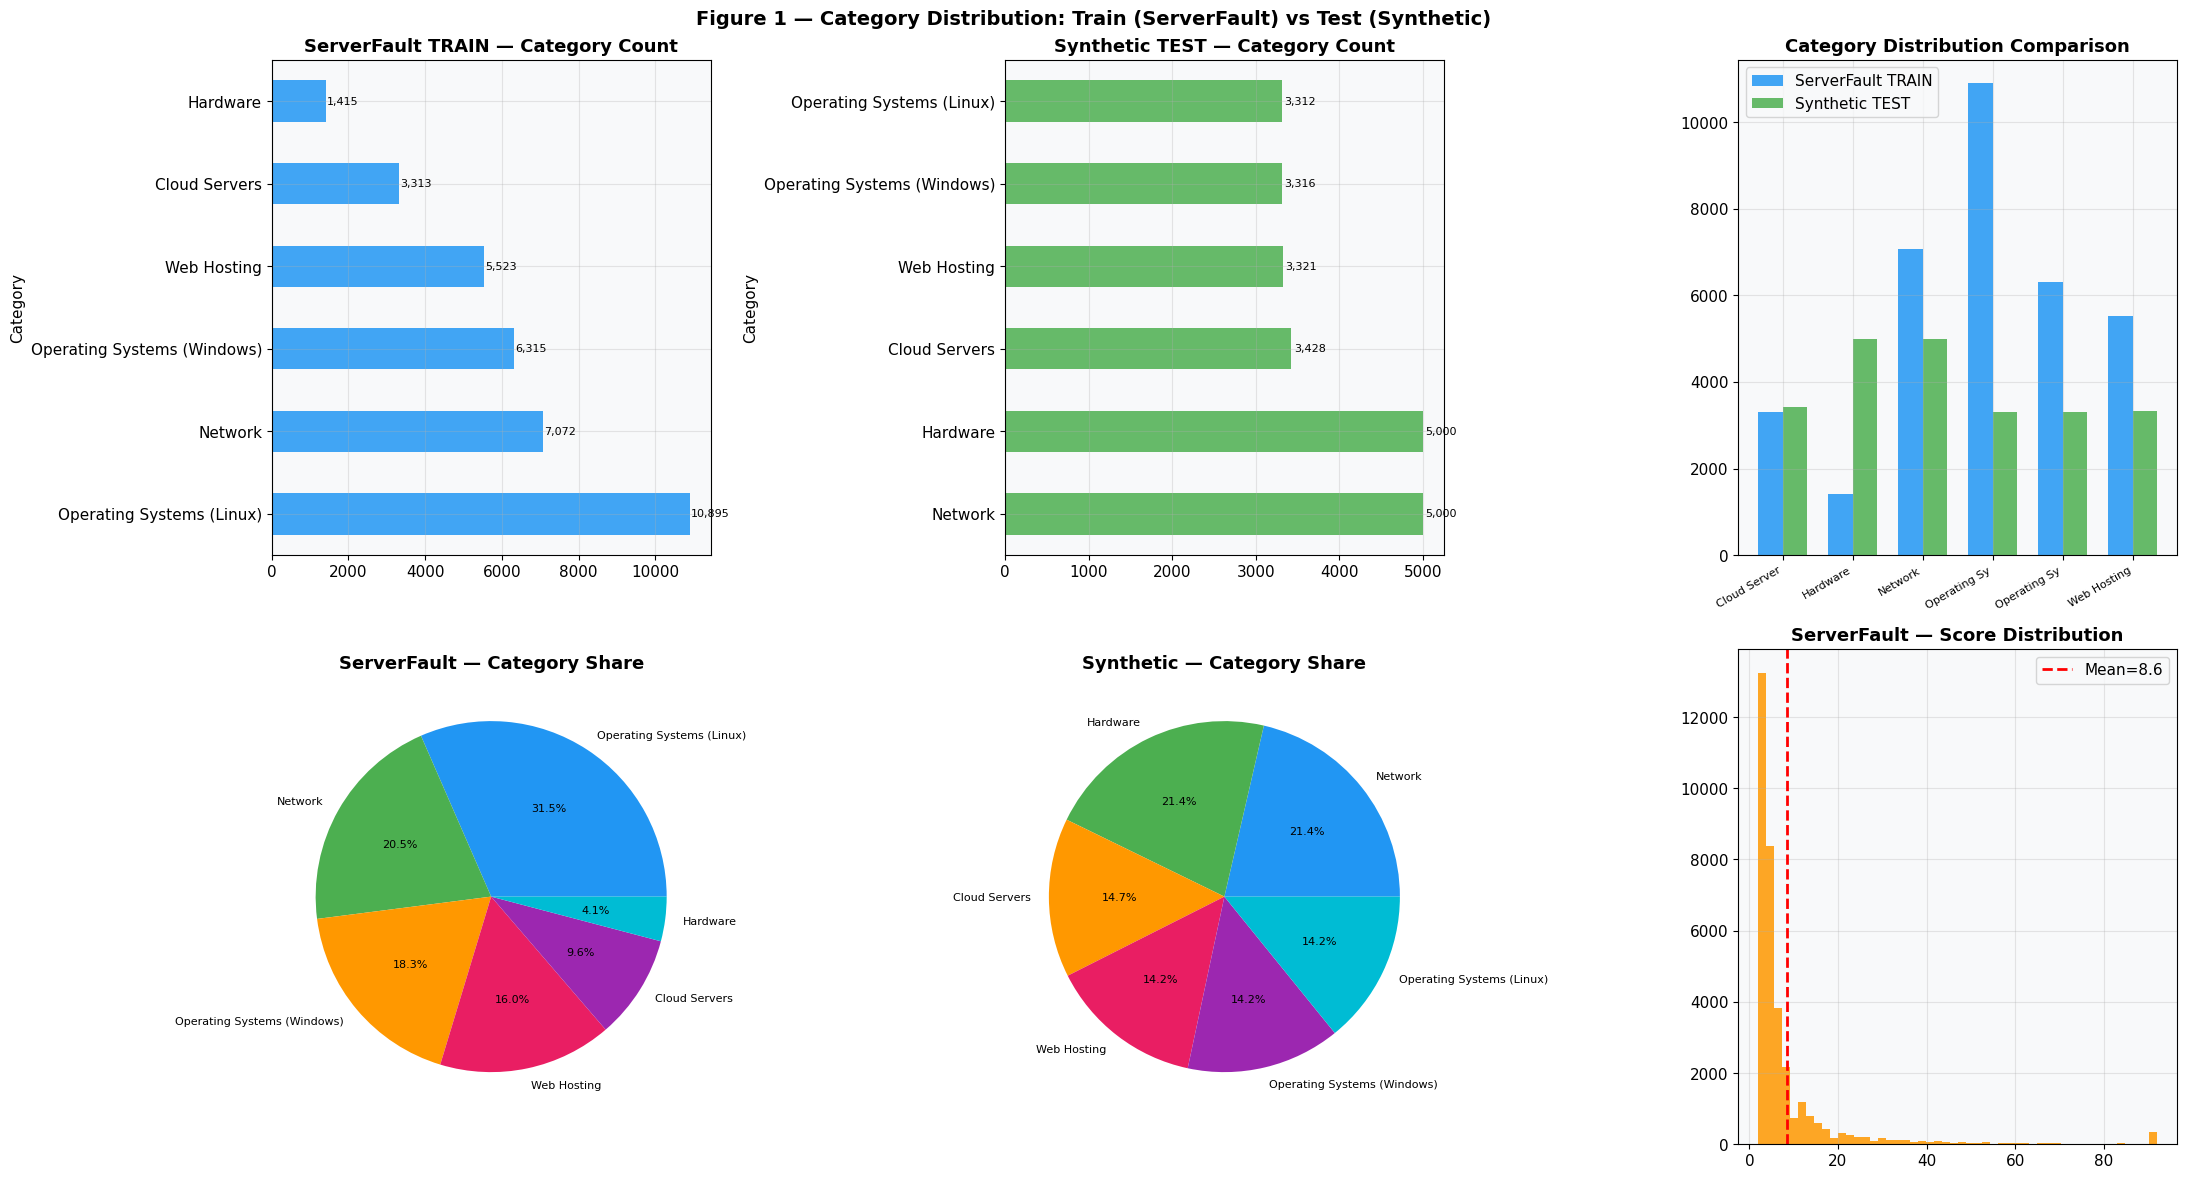

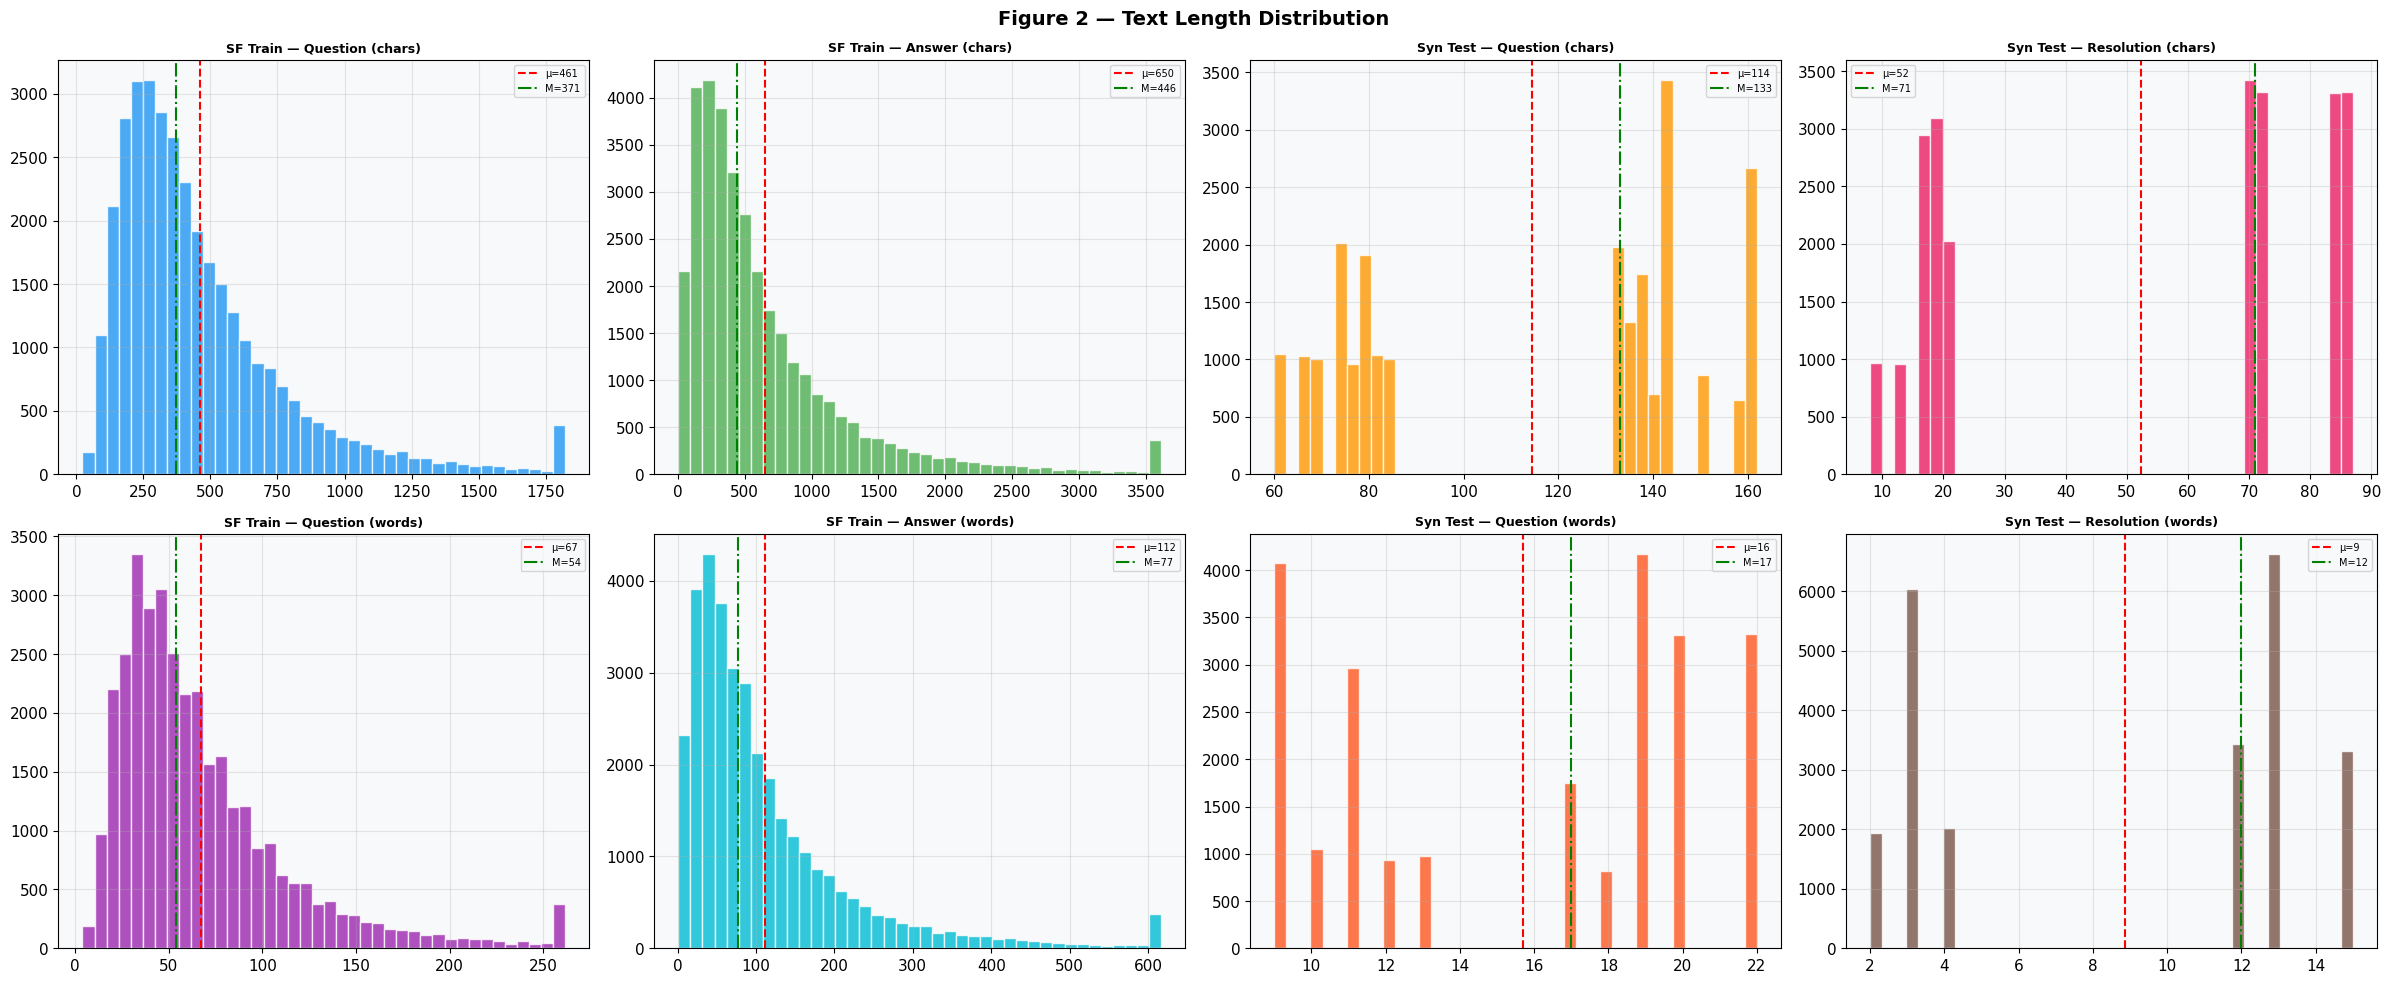

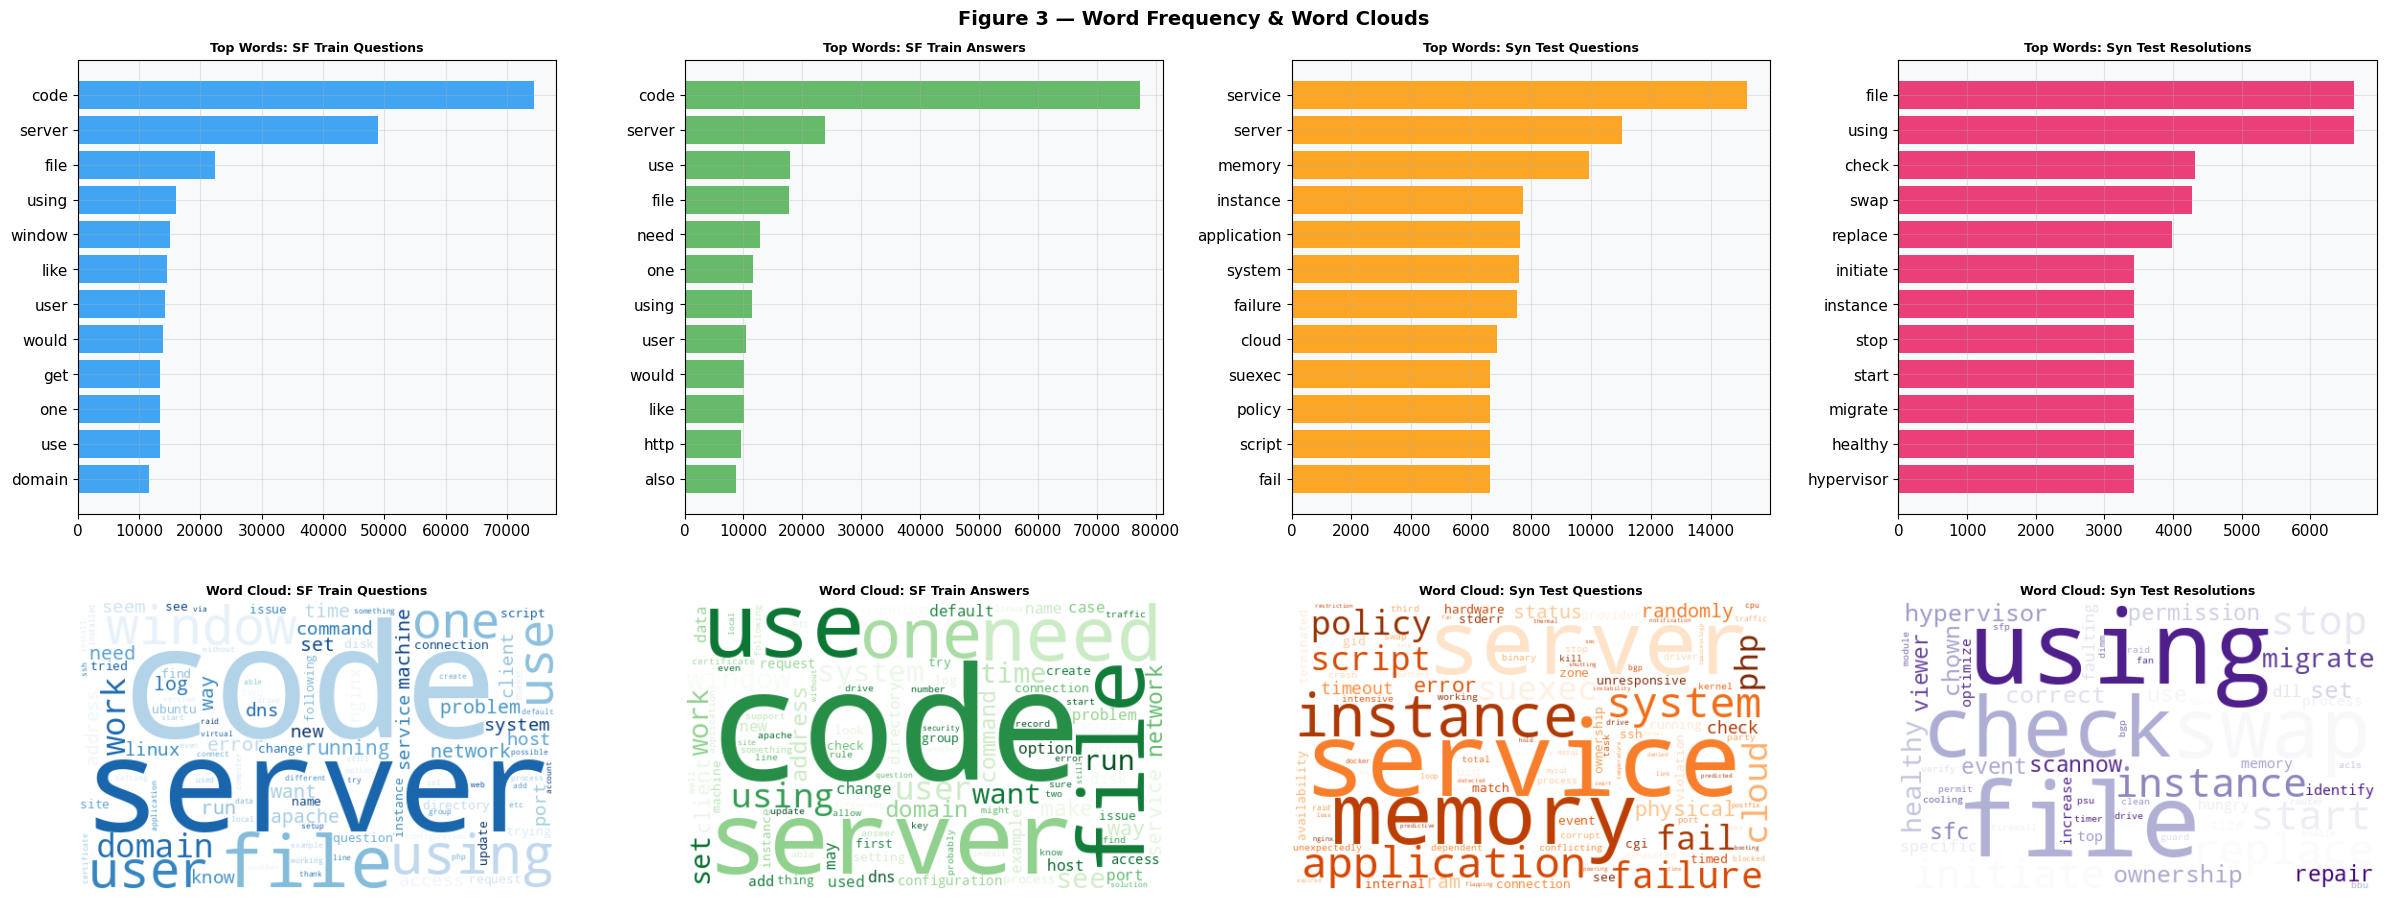

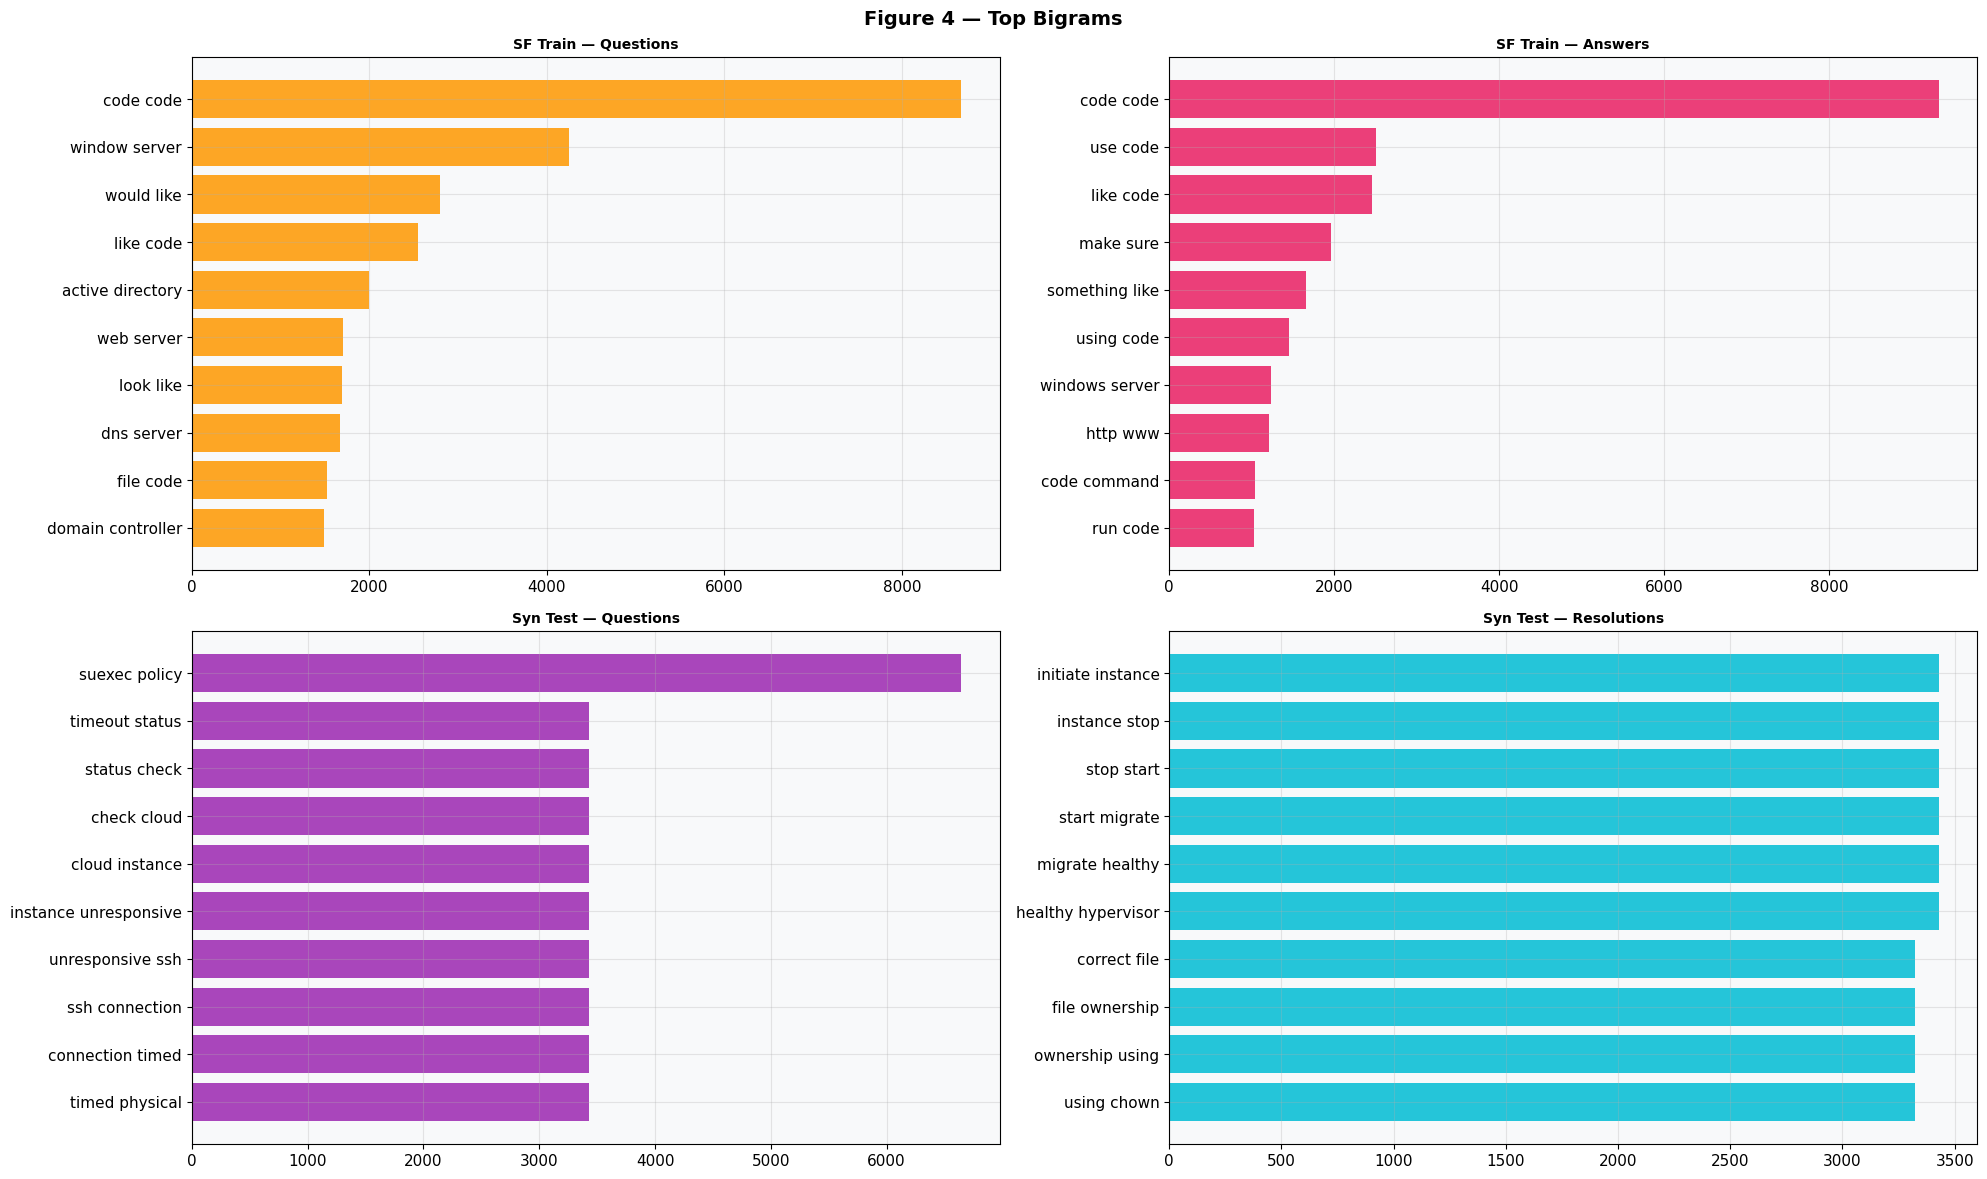

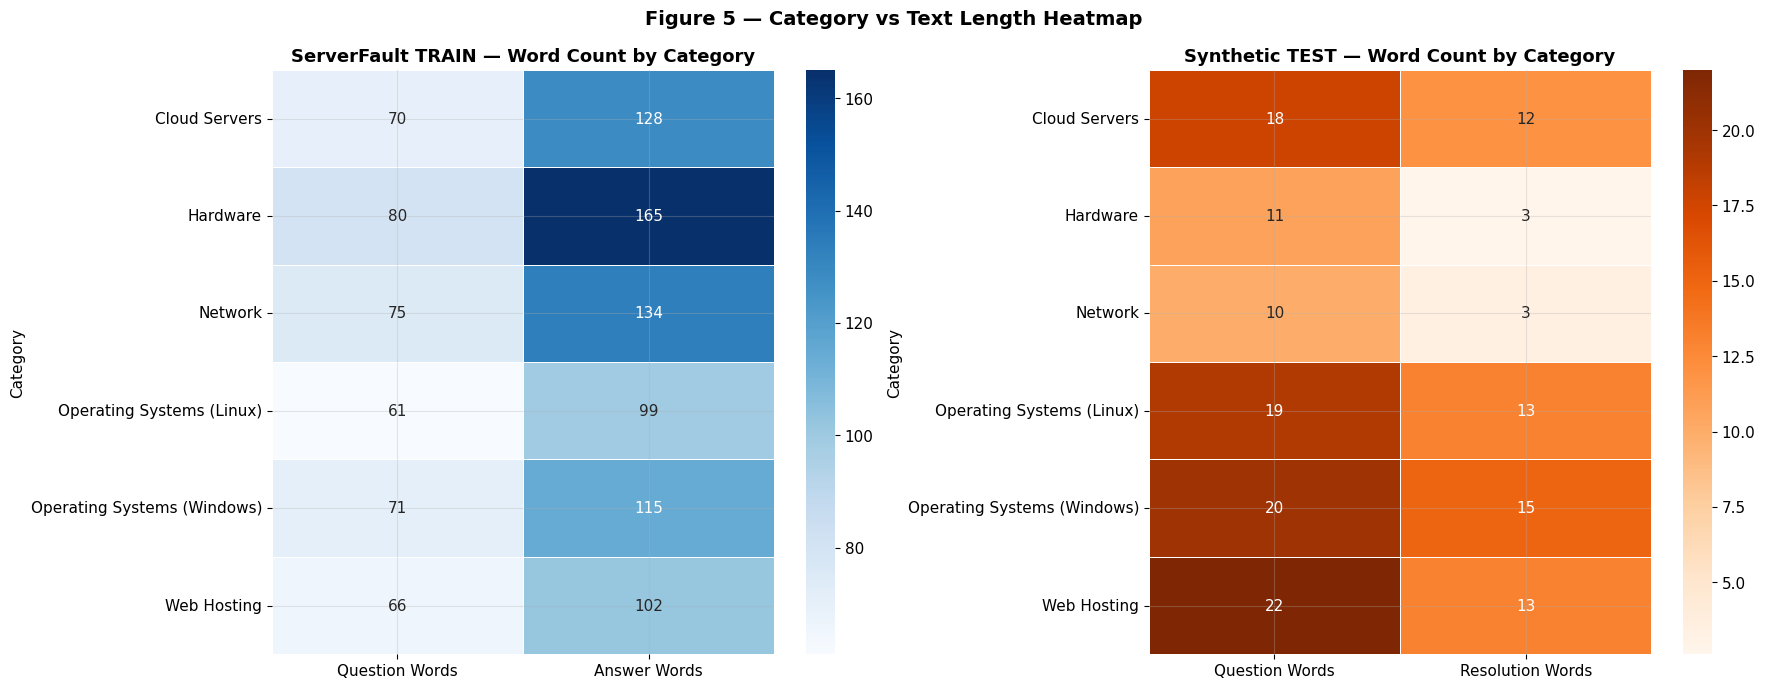

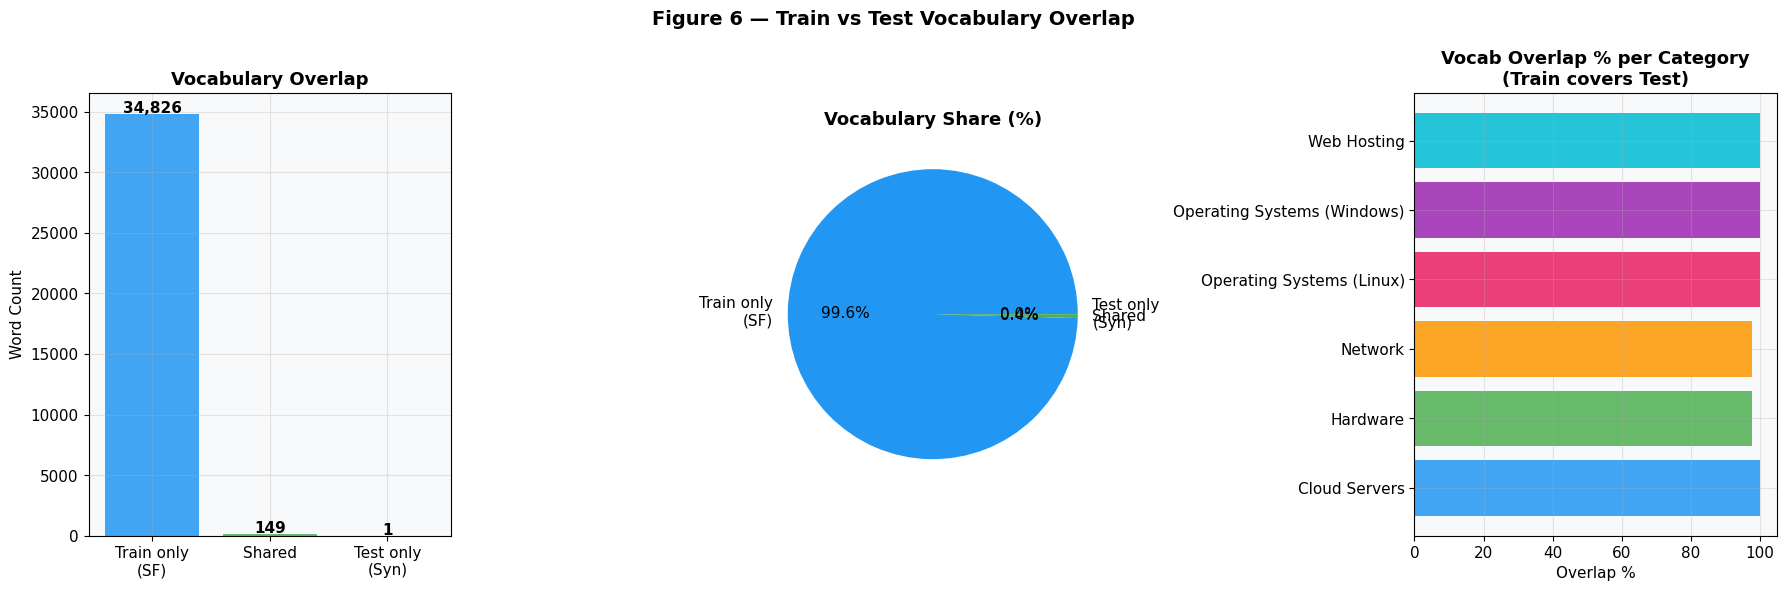


Vocabulary Summary:
  SF Train vocab      : 34,975
  Syn Test vocab      : 150
  Shared              : 149
  SF covers Syn       : 99.3%
  Syn covers SF       : 0.4%


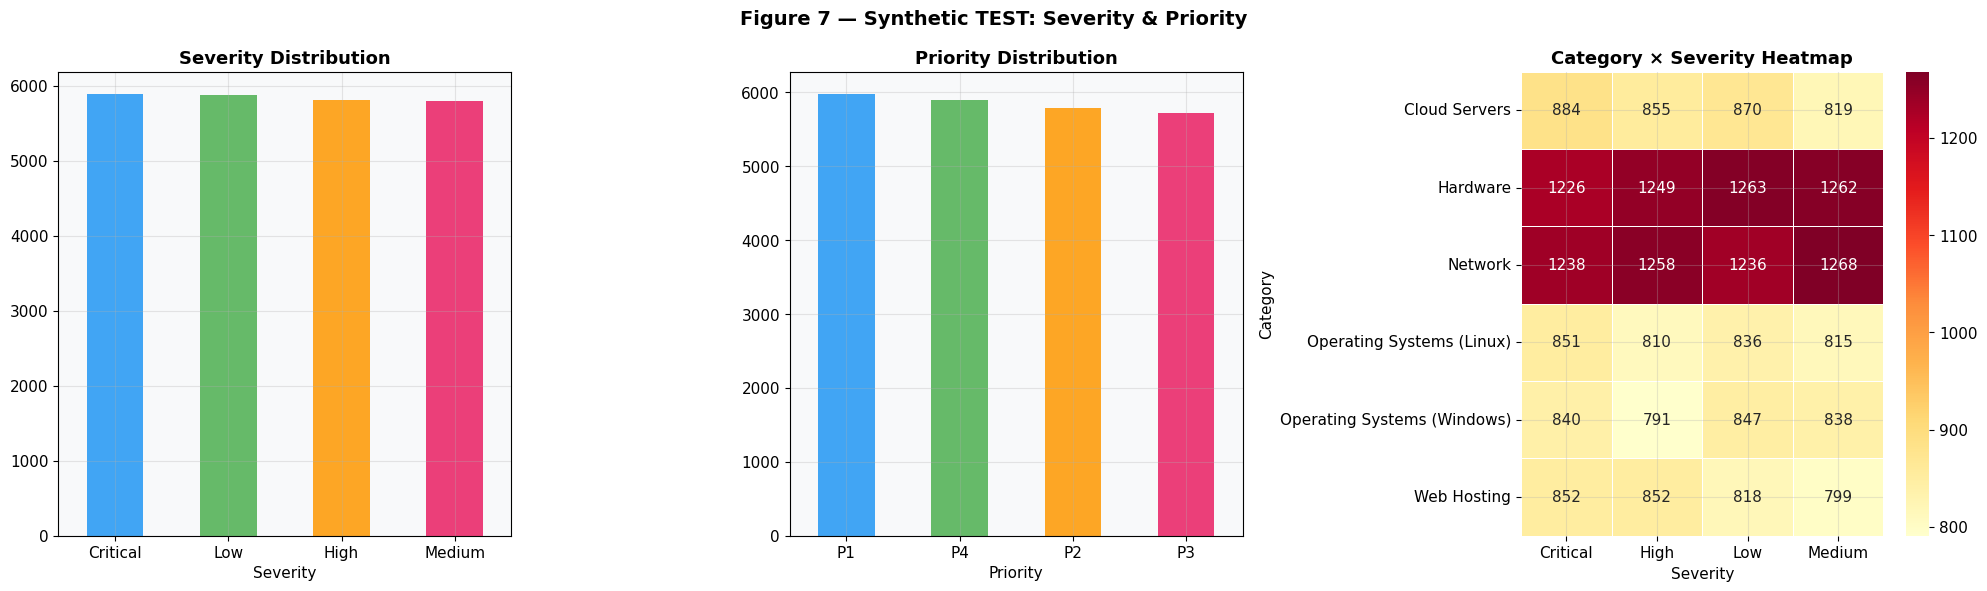

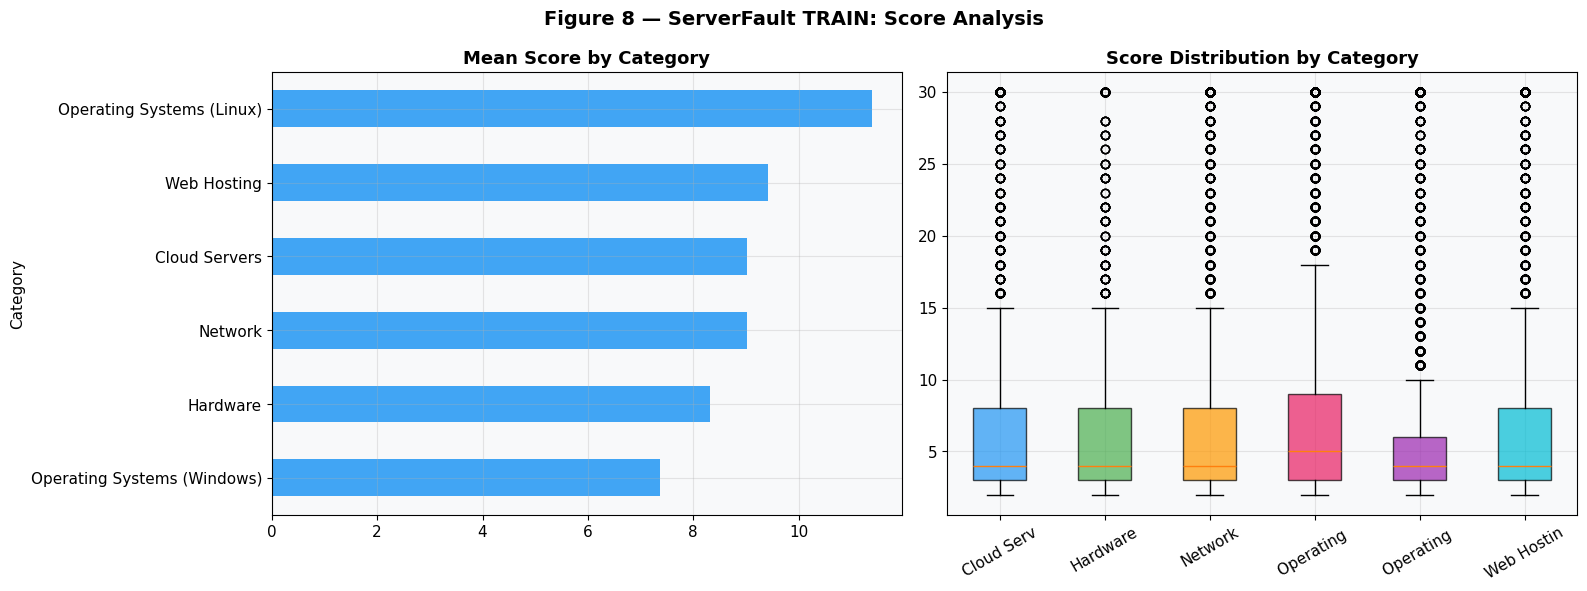


Kruskal-Wallis (Score ~ Category):
  H=235.5644  p=0.000000 — significant ✓

EDA complete — 8 figures saved ✓


In [4]:
print("="*65)
print("SECTION 2 — EXPLORATORY DATA ANALYSIS")
print("="*65)

def preprocess_eda(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|CODE','',text)
    text = re.sub(r'[^a-zA-Z ]',' ',text)
    tokens = [lemma.lemmatize(w) for w in text.split()
              if w not in STOP and len(w)>2]
    return ' '.join(tokens)

sf_6['text_eda']  = (sf_6['Title_clean']+' '+sf_6['Body_clean']).apply(preprocess_eda)
syn_6['text_eda'] = (syn_6['Error_Log_Trace'].astype(str)+' '+
                     syn_6['Symptom'].astype(str)+' '+
                     syn_6['Root_Cause'].astype(str)).apply(preprocess_eda)

for df,col in [(sf_6,'text_eda'),(syn_6,'text_eda'),
               (sf_6,'Answer_clean'),(syn_6,'Resolution_Steps')]:
    if col in df.columns:
        df[f'{col}_len'] = df[col].astype(str).apply(len)
        df[f'{col}_wc']  = df[col].astype(str).apply(
            lambda x: len(x.split()))

# ── Fig 1: Category Distribution ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Figure 1 — Category Distribution: Train (ServerFault) vs Test (Synthetic)',
             fontsize=14, fontweight='bold')

sf_vc.plot(kind='barh', ax=axes[0][0],
           color=CFG['COLORS'][0], alpha=0.85)
axes[0][0].set_title('ServerFault TRAIN — Category Count')
for i,v in enumerate(sf_vc):
    axes[0][0].text(v+30,i,f'{v:,}',va='center',fontsize=8)

syn_vc.plot(kind='barh', ax=axes[0][1],
            color=CFG['COLORS'][1], alpha=0.85)
axes[0][1].set_title('Synthetic TEST — Category Count')
for i,v in enumerate(syn_vc):
    axes[0][1].text(v+30,i,f'{v:,}',va='center',fontsize=8)

# Side by side bar
x     = np.arange(len(SHARED_CATS))
w     = 0.35
sf_v  = [sf_vc.get(c,0) for c in SHARED_CATS]
syn_v = [syn_vc.get(c,0) for c in SHARED_CATS]
axes[0][2].bar(x-w/2, sf_v,  w, label='ServerFault TRAIN',
               color=CFG['COLORS'][0], alpha=0.85)
axes[0][2].bar(x+w/2, syn_v, w, label='Synthetic TEST',
               color=CFG['COLORS'][1], alpha=0.85)
axes[0][2].set_xticks(x)
axes[0][2].set_xticklabels([c[:12] for c in SHARED_CATS],
                            rotation=30, ha='right', fontsize=8)
axes[0][2].set_title('Category Distribution Comparison')
axes[0][2].legend()

axes[1][0].pie(sf_vc.values, labels=sf_vc.index,
               autopct='%1.1f%%',
               colors=CFG['COLORS'][:len(sf_vc)],
               textprops={'fontsize':8})
axes[1][0].set_title('ServerFault — Category Share')

axes[1][1].pie(syn_vc.values, labels=syn_vc.index,
               autopct='%1.1f%%',
               colors=CFG['COLORS'][:len(syn_vc)],
               textprops={'fontsize':8})
axes[1][1].set_title('Synthetic — Category Share')

# Score distribution for SF
score_clip = sf_6['Score'].clip(upper=sf_6['Score'].quantile(0.99))
axes[1][2].hist(score_clip, bins=50,
                color=CFG['COLORS'][2], alpha=0.85)
axes[1][2].axvline(score_clip.mean(), color='red', ls='--',
                    lw=2, label=f"Mean={score_clip.mean():.1f}")
axes[1][2].set_title('ServerFault — Score Distribution')
axes[1][2].legend()
plt.tight_layout()
plt.savefig('fig1_category.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 2: Text Length ────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle('Figure 2 — Text Length Distribution',
             fontsize=14, fontweight='bold')

plot_pairs = [
    (sf_6,  'text_eda_len',         'SF Train — Question (chars)'),
    (sf_6,  'Answer_clean_len',      'SF Train — Answer (chars)'),
    (syn_6, 'text_eda_len',          'Syn Test — Question (chars)'),
    (syn_6, 'Resolution_Steps_len',  'Syn Test — Resolution (chars)'),
    (sf_6,  'text_eda_wc',           'SF Train — Question (words)'),
    (sf_6,  'Answer_clean_wc',       'SF Train — Answer (words)'),
    (syn_6, 'text_eda_wc',           'Syn Test — Question (words)'),
    (syn_6, 'Resolution_Steps_wc',   'Syn Test — Resolution (words)'),
]
for idx, (df, col, title) in enumerate(plot_pairs):
    ax  = axes[idx//4][idx%4]
    if col in df.columns:
        data = df[col].clip(upper=df[col].quantile(0.99))
        ax.hist(data, bins=40,
                color=CFG['COLORS'][idx%len(CFG['COLORS'])],
                alpha=0.8, edgecolor='white')
        ax.axvline(data.mean(), color='red', ls='--', lw=1.5,
                    label=f'μ={data.mean():.0f}')
        ax.axvline(data.median(), color='green', ls='-.', lw=1.5,
                    label=f'M={data.median():.0f}')
        ax.set_title(title, fontsize=9)
        ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('fig2_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 3: Word Clouds ────────────────────────────────────────────
def make_wc(df, col, colormap='Blues'):
    text  = ' '.join(df[col].astype(str))
    text  = re.sub(r'[^a-zA-Z ]',' ',text.lower())
    words = ' '.join([lemma.lemmatize(w) for w in text.split()
                      if w not in STOP and len(w)>2])
    return WordCloud(width=500, height=300,
                     background_color='white',
                     colormap=colormap,
                     max_words=100,
                     collocations=False).generate(words)

def top_words(df, col, n=12):
    text  = ' '.join(df[col].astype(str)).lower()
    text  = re.sub(r'[^a-zA-Z ]',' ',text)
    words = [lemma.lemmatize(w) for w in text.split()
             if w not in STOP and len(w)>2]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle('Figure 3 — Word Frequency & Word Clouds',
             fontsize=14, fontweight='bold')

wc_pairs = [
    (sf_6,  'text_eda',        'Blues',   'SF Train Questions'),
    (sf_6,  'Answer_clean',    'Greens',  'SF Train Answers'),
    (syn_6, 'text_eda',        'Oranges', 'Syn Test Questions'),
    (syn_6, 'Resolution_Steps','Purples', 'Syn Test Resolutions'),
]
for idx, (df, col, cmap, title) in enumerate(wc_pairs):
    # Top words
    ax = axes[0][idx]
    tw = top_words(df, col, 12)
    if tw:
        w,c = zip(*tw)
        ax.barh(list(reversed(w)), list(reversed(c)),
                color=CFG['COLORS'][idx], alpha=0.85)
    ax.set_title(f'Top Words: {title}', fontsize=9)
    # Word cloud
    ax2 = axes[1][idx]
    try:
        ax2.imshow(make_wc(df, col, cmap),
                   interpolation='bilinear')
    except: pass
    ax2.axis('off')
    ax2.set_title(f'Word Cloud: {title}', fontsize=9)
plt.tight_layout()
plt.savefig('fig3_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 4: Bigrams ────────────────────────────────────────────────
def top_bigrams(df, col, n=10):
    text   = ' '.join(df[col].astype(str)).lower()
    text   = re.sub(r'[^a-zA-Z ]',' ',text)
    words  = [w for w in text.split()
              if w not in STOP and len(w)>2]
    bigrams= [f"{words[i]} {words[i+1]}"
               for i in range(len(words)-1)]
    return Counter(bigrams).most_common(n)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Figure 4 — Top Bigrams',
             fontsize=14, fontweight='bold')
bg_pairs = [
    (sf_6,  'text_eda',        'SF Train — Questions'),
    (sf_6,  'Answer_clean',    'SF Train — Answers'),
    (syn_6, 'text_eda',        'Syn Test — Questions'),
    (syn_6, 'Resolution_Steps','Syn Test — Resolutions'),
]
for idx, (df, col, title) in enumerate(bg_pairs):
    ax = axes[idx//2][idx%2]
    bg = top_bigrams(df, col, 10)
    if bg:
        b,c = zip(*bg)
        ax.barh(list(reversed(b)), list(reversed(c)),
                color=CFG['COLORS'][(idx+2)%len(CFG['COLORS'])],
                alpha=0.85)
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.savefig('fig4_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 5: Category × Length Heatmap ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Figure 5 — Category vs Text Length Heatmap',
             fontsize=14, fontweight='bold')

p1 = sf_6.groupby('Category')[
    ['text_eda_wc','Answer_clean_wc']].mean()
p1.columns = ['Question Words','Answer Words']
sns.heatmap(p1, annot=True, fmt='.0f', cmap='Blues',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('ServerFault TRAIN — Word Count by Category')

p2 = syn_6.groupby('Category')[
    ['text_eda_wc','Resolution_Steps_wc']].mean()
p2.columns = ['Question Words','Resolution Words']
sns.heatmap(p2, annot=True, fmt='.0f', cmap='Oranges',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Synthetic TEST — Word Count by Category')
plt.tight_layout()
plt.savefig('fig5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 6: Vocabulary Overlap ─────────────────────────────────────
sf_vocab  = set(' '.join(sf_6['text_eda']).split())
syn_vocab = set(' '.join(syn_6['text_eda']).split())
only_sf   = len(sf_vocab - syn_vocab)
shared    = len(sf_vocab & syn_vocab)
only_syn  = len(syn_vocab - sf_vocab)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 6 — Train vs Test Vocabulary Overlap',
             fontsize=14, fontweight='bold')
vals  = [only_sf, shared, only_syn]
labs  = ['Train only\n(SF)','Shared','Test only\n(Syn)']
bars  = axes[0].bar(labs, vals,
                     color=['#2196F3','#4CAF50','#FF9800'],
                     alpha=0.85)
axes[0].set_title('Vocabulary Overlap')
axes[0].set_ylabel('Word Count')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h+100,
                  f'{int(h):,}', ha='center', fontweight='bold')

axes[1].pie([only_sf, shared, only_syn],
            labels=labs, autopct='%1.1f%%',
            colors=['#2196F3','#4CAF50','#FF9800'])
axes[1].set_title('Vocabulary Share (%)')

cats_overlap = []
for cat in SHARED_CATS:
    sv = set(' '.join(sf_6[sf_6['Category']==cat]['text_eda']).split())
    tv = set(' '.join(syn_6[syn_6['Category']==cat]['text_eda']).split())
    ov = len(sv & tv)/len(tv)*100 if tv else 0
    cats_overlap.append(ov)
axes[2].barh(SHARED_CATS, cats_overlap,
             color=CFG['COLORS'][:len(SHARED_CATS)], alpha=0.85)
axes[2].set_title('Vocab Overlap % per Category\n(Train covers Test)')
axes[2].set_xlabel('Overlap %')
plt.tight_layout()
plt.savefig('fig6_vocab_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVocabulary Summary:")
print(f"  SF Train vocab      : {len(sf_vocab):,}")
print(f"  Syn Test vocab      : {len(syn_vocab):,}")
print(f"  Shared              : {shared:,}")
print(f"  SF covers Syn       : {shared/len(syn_vocab)*100:.1f}%")
print(f"  Syn covers SF       : {shared/len(sf_vocab)*100:.1f}%")

# ── Fig 7: Severity & Priority (Synthetic) ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Figure 7 — Synthetic TEST: Severity & Priority',
             fontsize=14, fontweight='bold')
sev_vc = syn_6['Severity'].value_counts()
pri_vc = syn_6['Priority'].value_counts()
sev_vc.plot(kind='bar', ax=axes[0],
            color=CFG['COLORS'][:len(sev_vc)], rot=0, alpha=0.85)
axes[0].set_title('Severity Distribution')
pri_vc.plot(kind='bar', ax=axes[1],
            color=CFG['COLORS'][:len(pri_vc)], rot=0, alpha=0.85)
axes[1].set_title('Priority Distribution')
pivot = pd.crosstab(syn_6['Category'], syn_6['Severity'])
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            ax=axes[2], linewidths=0.5)
axes[2].set_title('Category × Severity Heatmap')
plt.tight_layout()
plt.savefig('fig7_severity.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 8: Score by Category (ServerFault) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 8 — ServerFault TRAIN: Score Analysis',
             fontsize=14, fontweight='bold')
sf_6.groupby('Category')['Score'].mean().sort_values().plot(
    kind='barh', ax=axes[0],
    color=CFG['COLORS'][0], alpha=0.85)
axes[0].set_title('Mean Score by Category')
score_by_cat = [sf_6[sf_6['Category']==c]['Score'].clip(
    upper=sf_6['Score'].quantile(0.95)).values
    for c in SHARED_CATS]
bp = axes[1].boxplot(score_by_cat,
                      labels=[c[:10] for c in SHARED_CATS],
                      patch_artist=True)
for patch,color in zip(bp['boxes'],CFG['COLORS'][:len(SHARED_CATS)]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Score Distribution by Category')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('fig8_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistical Test ──────────────────────────────────────────────
groups = [sf_6[sf_6['Category']==c]['Score'].values
           for c in SHARED_CATS]
stat, pval = kruskal(*groups)
print(f"\nKruskal-Wallis (Score ~ Category):")
print(f"  H={stat:.4f}  p={pval:.6f} "
      f"{'— significant ✓' if pval<0.05 else '— not significant'}")

print(f"\nEDA complete — 8 figures saved ✓")

SECTION 3 — PREPROCESSING
Preprocessing done in 28.2s

Split summary:
  TRAIN (SF balanced)  : 8,490 (1,415/class)
  TEST  (Syn balanced) : 19,872 (3,312/class)
  Classes              : ['Cloud Servers' 'Hardware' 'Network' 'Operating Systems (Linux)'
 'Operating Systems (Windows)' 'Web Hosting']

TF-IDF features : 25,000

Loading GloVe 100d...
GloVe ✓ — 62.8% coverage
Loading FastText...
[==================================================] 100.0% 958.5/958.4MB downloaded
FastText ✓ dim=300
Loading Word2Vec...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec ✓ dim=300


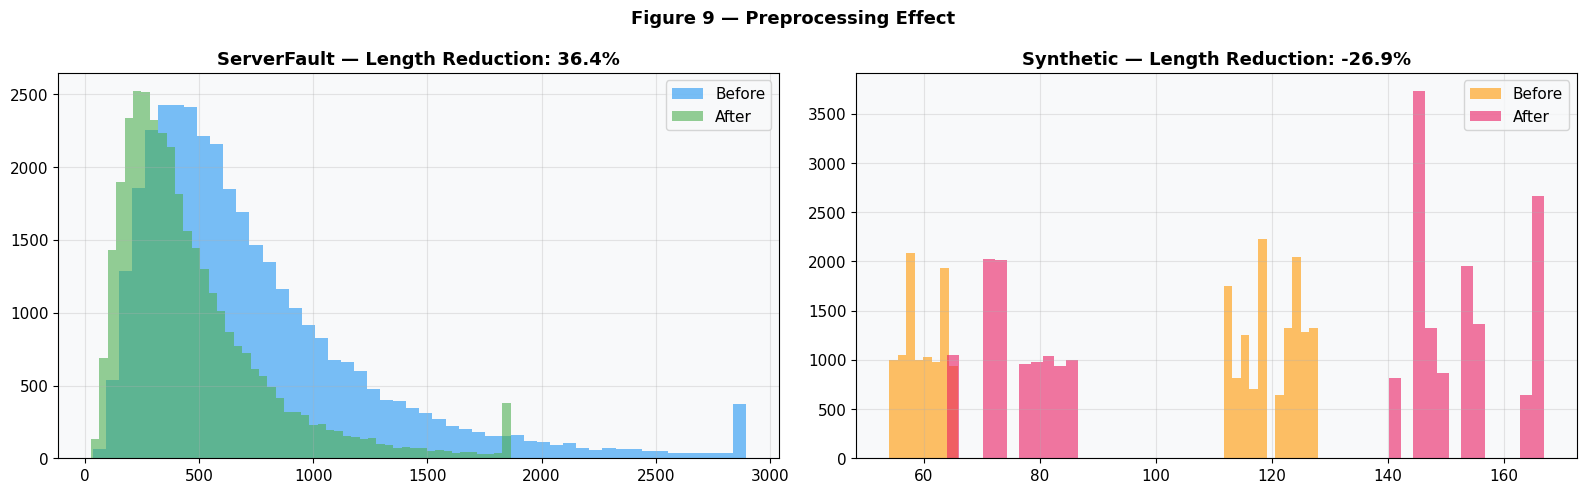


All features ready ✓


In [5]:
print("="*65)
print("SECTION 3 — PREPROCESSING")
print("="*65)

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|CODE','url',text)
    text = re.sub(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b','ipaddr',text)
    text = re.sub(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z]{2,}','email',text)
    text = re.sub(r'\b\d+\.\d+[\.\d]*\b','version',text)
    text = re.sub(r'[^a-zA-Z0-9 ]',' ',text)
    text = re.sub(r'\s+',' ',text).strip()
    tokens = [lemma.lemmatize(w) for w in text.split()
              if w not in STOP and len(w)>2]
    return ' '.join(tokens)

t0 = time.time()

# ServerFault TRAIN
sf_6['text']      = (sf_6['Title_clean'] + ' ' +
                      sf_6['Body_clean']).apply(preprocess)
sf_6['gen_input'] = sf_6.apply(
    lambda r: f"question: {str(r['Title_clean']).strip()} "
              f"details: {str(r['Body_clean'])[:300].strip()}", axis=1)
sf_6['answer_proc'] = sf_6['Answer_clean'].apply(preprocess)

# Synthetic TEST
syn_6['text']     = (syn_6['Error_Log_Trace'].astype(str) + ' ' +
                     syn_6['Symptom'].astype(str) + ' ' +
                     syn_6['Root_Cause'].astype(str)).apply(preprocess)
syn_6['gen_input']= syn_6.apply(
    lambda r: f"symptom: {str(r['Symptom']).strip()} "
              f"error: {str(r['Error_Log_Trace'])[:200].strip()} "
              f"cause: {str(r['Root_Cause'])[:200].strip()}", axis=1)

print(f"Preprocessing done in {time.time()-t0:.1f}s")

# ── TRAIN set: ServerFault balanced ──────────────────────────────
min_sf  = sf_6['Category'].value_counts().min()
sf_bal  = pd.concat([
    resample(sf_6[sf_6['Category']==c],
             n_samples=min_sf, random_state=42)
    for c in SHARED_CATS
]).reset_index(drop=True)

# ── TEST set: Synthetic balanced ──────────────────────────────────
# Only resample for categories present in syn_6
min_syn = syn_6['Category'].value_counts().min()
syn_bal = pd.concat([
    resample(syn_6[syn_6['Category']==c],
             n_samples=min_syn, random_state=42)
    for c in syn_6['Category'].unique() # Modified this line
]).reset_index(drop=True)

X_train = sf_bal['text']
X_test  = syn_bal['text']
le      = LabelEncoder()
y_train = le.fit_transform(sf_bal['Category'])
y_test  = le.transform(syn_bal['Category'])
N_CLS   = len(le.classes_)

print(f"\nSplit summary:")
print(f"  TRAIN (SF balanced)  : {len(X_train):,} "
      f"({min_sf:,}/class)")
print(f"  TEST  (Syn balanced) : {len(X_test):,} "
      f"({min_syn:,}/class)")
print(f"  Classes              : {le.classes_}")

# ── TF-IDF ────────────────────────────────────────────────────────
tfidf    = TfidfVectorizer(max_features=25000, ngram_range=(1,2),
                            sublinear_tf=True, min_df=2)
X_tr_tf  = tfidf.fit_transform(X_train)
X_te_tf  = tfidf.transform(X_test)
tfidf_nb = TfidfVectorizer(max_features=25000, ngram_range=(1,2),
                            min_df=2)
X_tr_nb  = tfidf_nb.fit_transform(X_train)
X_te_nb  = tfidf_nb.transform(X_test)
print(f"\nTF-IDF features : {X_tr_tf.shape[1]:,}")

# ── Keras tokenizer ───────────────────────────────────────────────
keras_tok = KTok(num_words=CFG['MAX_WORDS'], oov_token='<OOV>')
keras_tok.fit_on_texts(X_train)
X_tr_seq  = pad_sequences(
    keras_tok.texts_to_sequences(X_train),
    maxlen=CFG['MAX_LEN'], padding='post')
X_te_seq  = pad_sequences(
    keras_tok.texts_to_sequences(X_test),
    maxlen=CFG['MAX_LEN'], padding='post')
y_tr_cat  = to_categorical(y_train, N_CLS)
y_te_cat  = to_categorical(y_test,  N_CLS)

# Class weights
cw_dict = dict(enumerate(
    len(y_train) / (N_CLS * np.bincount(y_train))
))

# ── GloVe ────────────────────────────────────────────────────────
print("\nLoading GloVe 100d...")
glove_idx = {}
with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        vals = line.split()
        glove_idx[vals[0]] = np.array(vals[1:], dtype='float32')
glove_mat = np.zeros((CFG['MAX_WORDS'], CFG['EMBED_DIM']))
hit = 0
for word, i in keras_tok.word_index.items():
    if i < CFG['MAX_WORDS'] and word in glove_idx:
        glove_mat[i] = glove_idx[word]; hit += 1
cov = hit/min(len(keras_tok.word_index),CFG['MAX_WORDS'])*100
print(f"GloVe \u2713 — {cov:.1f}% coverage")

# ── FastText ──────────────────────────────────────────────────────
print("Loading FastText...")
try:
    import gensim.downloader as gapi
    ft_mdl = gapi.load('fasttext-wiki-news-subwords-300')
    FT_DIM = 300
    ft_mat = np.zeros((CFG['MAX_WORDS'], FT_DIM))
    for word, i in keras_tok.word_index.items():
        if i < CFG['MAX_WORDS']:
            try: ft_mat[i] = ft_mdl[word][:FT_DIM]
            except: pass
    ft_ok = True; print(f"FastText \u2713 dim={FT_DIM}")
except Exception as e:
    ft_mat = glove_mat; FT_DIM = CFG['EMBED_DIM']
    ft_ok = False; print(f"FastText fallback: {e}")

# ── Word2Vec ──────────────────────────────────────────────────────
print("Loading Word2Vec...")
try:
    w2v_mdl = gapi.load('word2vec-google-news-300')
    W2V_DIM = 300
    w2v_mat = np.zeros((CFG['MAX_WORDS'], W2V_DIM))
    for word, i in keras_tok.word_index.items():
        if i < CFG['MAX_WORDS']:
            try: w2v_mat[i] = w2v_mdl[word][:W2V_DIM]
            except: pass
    w2v_ok = True; print(f"Word2Vec \u2713 dim={W2V_DIM}")
except Exception as e:
    w2v_mat = glove_mat; W2V_DIM = CFG['EMBED_DIM']
    w2v_ok = False; print(f"Word2Vec fallback: {e}")

# ── Fig 9: Preprocessing effect ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Figure 9 — Preprocessing Effect',
             fontsize=13, fontweight='bold')
raw_sf  = (sf_6['Title_clean']+' '+sf_6['Body_clean']).apply(len)
proc_sf = sf_6['text'].apply(len)
axes[0].hist(raw_sf.clip(upper=raw_sf.quantile(0.99)),
             bins=50, color=CFG['COLORS'][0],
             alpha=0.6, label='Before')
axes[0].hist(proc_sf.clip(upper=proc_sf.quantile(0.99)),
             bins=50, color=CFG['COLORS'][1],
             alpha=0.6, label='After')
axes[0].set_title(f'ServerFault — Length Reduction: '
                   f'{(1-proc_sf.mean()/raw_sf.mean())*100:.1f}%')
axes[0].legend()

raw_syn  = (syn_6['Error_Log_Trace'].astype(str)+' '+
            syn_6['Symptom'].astype(str)).apply(len)
proc_syn = syn_6['text'].apply(len)
axes[1].hist(raw_syn.clip(upper=raw_syn.quantile(0.99)),
             bins=50, color=CFG['COLORS'][2],
             alpha=0.6, label='Before')
axes[1].hist(proc_syn.clip(upper=proc_syn.quantile(0.99)),
             bins=50, color=CFG['COLORS'][3],
             alpha=0.6, label='After')
axes[1].set_title(f'Synthetic — Length Reduction: '
                   f'{(1-proc_syn.mean()/raw_syn.mean())*100:.1f}%')
axes[1].legend()
plt.tight_layout()
plt.savefig('fig9_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll features ready \u2713")

SECTION 4 — CONVENTIONAL & BOOSTING MODELS
  ✓ Decision Tree               [TF-IDF         ] Acc:0.4635 F1w:0.4711 F1m:0.4711 (11.9s)
  ✓ Logistic Reg                [TF-IDF         ] Acc:0.7669 F1w:0.7213 F1m:0.7213 (9.6s)
  ✓ SVM                         [TF-IDF         ] Acc:0.7669 F1w:0.7213 F1m:0.7213 (1.5s)
  ✓ KNN                         [TF-IDF         ] Acc:0.9362 F1w:0.9357 F1m:0.9357 (5.7s)
  ✓ Naive Bayes                 [TF-IDF         ] Acc:1.0000 F1w:1.0000 F1m:1.0000 (0.2s)
  ✓ Random Forest               [TF-IDF         ] Acc:0.8000 F1w:0.7309 F1m:0.7309 (98.0s)
  ✓ AdaBoost                    [TF-IDF         ] Acc:0.2020 F1w:0.2093 F1m:0.2093 (23.2s)
  ✓ Gradient Boost              [TF-IDF         ] Acc:0.4978 F1w:0.4527 F1m:0.4527 (284.1s)
  ✓ XGBoost                     [TF-IDF         ] Acc:0.5335 F1w:0.4841 F1m:0.4841 (184.3s)
  ✓ LightGBM                    [TF-IDF         ] Acc:0.5308 F1w:0.4730 F1m:0.4730 (594.0s)
  ✓ CatBoost                    [TF-IDF         

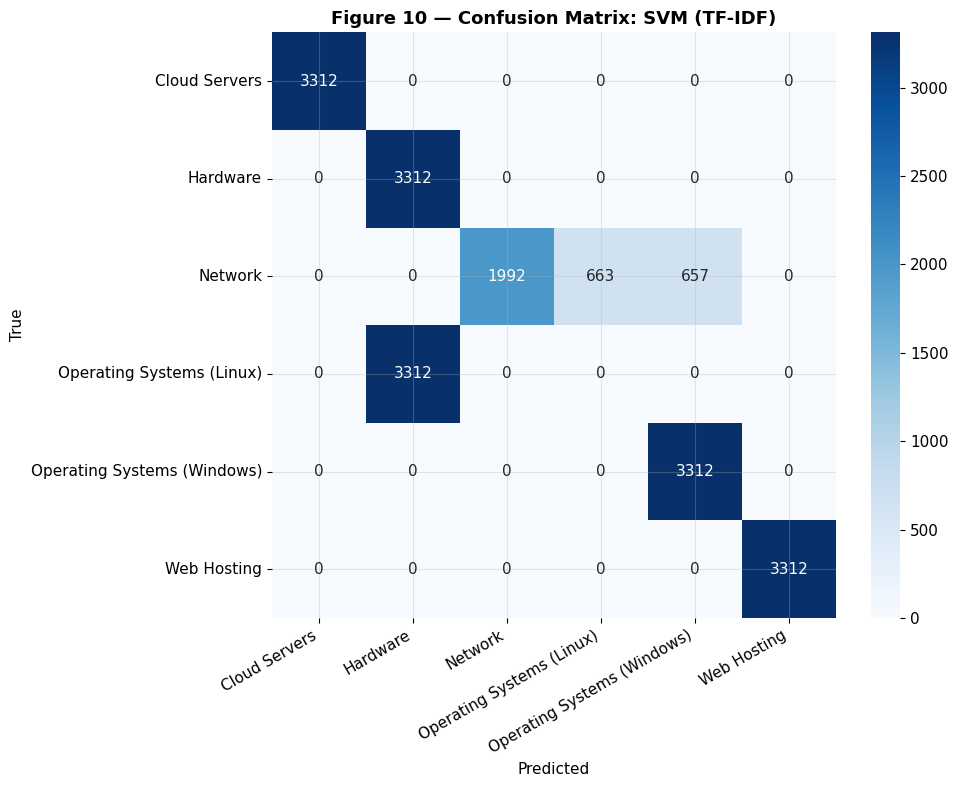

                             precision    recall  f1-score   support

              Cloud Servers       1.00      1.00      1.00      3312
                   Hardware       0.50      1.00      0.67      3312
                    Network       1.00      0.60      0.75      3312
  Operating Systems (Linux)       0.00      0.00      0.00      3312
Operating Systems (Windows)       0.83      1.00      0.91      3312
                Web Hosting       1.00      1.00      1.00      3312

                   accuracy                           0.77     19872
                  macro avg       0.72      0.77      0.72     19872
               weighted avg       0.72      0.77      0.72     19872



In [6]:
print("="*65)
print("SECTION 4 — CONVENTIONAL & BOOSTING MODELS")
print("="*65)

CLASSIFIERS = {
    'Decision Tree'  : (DecisionTreeClassifier(random_state=42),
                        {'max_depth':[10,20,None]}),
    'Logistic Reg'   : (LogisticRegression(max_iter=1000,
                         class_weight='balanced'),
                        {'C':[0.1,1,10]}),
    'SVM'            : (LinearSVC(max_iter=2000,
                         class_weight='balanced'),
                        {'C':[0.1,1,10]}),
    'KNN'            : (KNeighborsClassifier(),
                        {'n_neighbors':[3,5,7]}),
    'Naive Bayes'    : (MultinomialNB(),
                        {'alpha':[0.1,0.5,1.0]}),
    'Random Forest'  : (RandomForestClassifier(random_state=42,
                         class_weight='balanced'),
                        {'n_estimators':[100,200]}),
    'AdaBoost'       : (AdaBoostClassifier(random_state=42),
                        {'n_estimators':[50,100]}),
    'Gradient Boost' : (GradientBoostingClassifier(random_state=42),
                        {'n_estimators':[100]}),
    'XGBoost'        : (XGBClassifier(eval_metric='mlogloss',
                         verbosity=0, random_state=42),
                        {'n_estimators':[100],
                         'max_depth':[5,10]}),
    'LightGBM'       : (LGBMClassifier(verbosity=-1,
                         random_state=42),
                        {'n_estimators':[100],
                         'max_depth':[5,10]}),
    'CatBoost'       : (CatBoostClassifier(verbose=0,
                         random_state=42),
                        {'iterations':[100],'depth':[5,8]}),
    'MLP'            : (MLPClassifier(max_iter=300,
                         random_state=42),
                        {'hidden_layer_sizes':
                         [(128,),(256,128)]}),
}

for name, (model, params) in CLASSIFIERS.items():
    t0 = time.time()
    try:
        Xtr = X_tr_nb if name=='Naive Bayes' else X_tr_tf
        Xte = X_te_nb if name=='Naive Bayes' else X_te_tf
        gs  = GridSearchCV(model, params, cv=3,
                            scoring='f1_weighted', n_jobs=-1)
        gs.fit(Xtr, y_train)
        yp  = gs.best_estimator_.predict(Xte)
        record_clf(name,'TF-IDF',
            accuracy_score(y_test,yp),
            f1_score(y_test,yp,average='weighted',zero_division=0),
            f1_score(y_test,yp,average='macro',zero_division=0),
            time.time()-t0)
    except Exception as e:
        print(f"  ✗ {name}: {e}")

# Stacking
t0 = time.time()
try:
    base = [
        ('lr',  LogisticRegression(max_iter=1000,C=1,
                class_weight='balanced')),
        ('svm', LinearSVC(max_iter=2000,C=1,
                class_weight='balanced')),
        ('rf',  RandomForestClassifier(n_estimators=100,
                random_state=42,class_weight='balanced')),
        ('xgb', XGBClassifier(n_estimators=100,
                eval_metric='mlogloss',verbosity=0,
                random_state=42)),
    ]
    stack = StackingClassifier(
        estimators=base,
        final_estimator=LogisticRegression(max_iter=500),
        cv=3, n_jobs=-1)
    stack.fit(X_tr_tf, y_train)
    yp = stack.predict(X_te_tf)
    record_clf('Stacking Ensemble','TF-IDF',
        accuracy_score(y_test,yp),
        f1_score(y_test,yp,average='weighted',zero_division=0),
        f1_score(y_test,yp,average='macro',zero_division=0),
        time.time()-t0)
except Exception as e:
    print(f"  ✗ Stacking: {e}")

# Voting
t0 = time.time()
try:
    vote = VotingClassifier([
        ('lr',  LogisticRegression(max_iter=1000,C=1,
                class_weight='balanced')),
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('rf',  RandomForestClassifier(n_estimators=100,
                random_state=42,class_weight='balanced')),
    ], voting='hard', n_jobs=-1)
    vote.fit(X_tr_tf, y_train)
    yp = vote.predict(X_te_tf)
    record_clf('Voting Ensemble','TF-IDF',
        accuracy_score(y_test,yp),
        f1_score(y_test,yp,average='weighted',zero_division=0),
        f1_score(y_test,yp,average='macro',zero_division=0),
        time.time()-t0)
except Exception as e:
    print(f"  ✗ Voting: {e}")

# Cross-validation
print("\n5-Fold CV (SVM on train):")
cv = cross_val_score(
    LinearSVC(max_iter=2000,C=1,class_weight='balanced'),
    X_tr_tf, y_train, cv=5, scoring='f1_weighted')
print(f"  Scores : {[round(s,4) for s in cv]}")
print(f"  Mean   : {cv.mean():.4f} ± {cv.std():.4f}")

# Best model confusion matrix
best_svm = LinearSVC(max_iter=2000,C=1,class_weight='balanced')
best_svm.fit(X_tr_tf, y_train)
yp_svm = best_svm.predict(X_te_tf)
cm = confusion_matrix(y_test, yp_svm)
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_,
            yticklabels=le.classes_)
ax.set_title('Figure 10 — Confusion Matrix: SVM (TF-IDF)',
              fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=30,ha='right')
plt.tight_layout()
plt.savefig('fig10_confusion_svm.png',dpi=150,bbox_inches='tight')
plt.show()
print(classification_report(y_test, yp_svm,
      target_names=le.classes_, zero_division=0))

In [7]:
print("="*65)
print("SECTION 5 — DEEP LEARNING MODELS")
print("="*65)

ES  = EarlyStopping(monitor='val_loss', patience=CFG['PATIENCE'],
                     restore_best_weights=True, verbose=0)
RLR = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                         patience=2, verbose=0)

def make_emb(mat, dim):
    return Embedding(CFG['MAX_WORDS'], dim, weights=[mat],
                     input_length=CFG['MAX_LEN'],
                     trainable=False)

def build_models(emb_fn, dim):
    return {
        'LSTM'        : Sequential([emb_fn(),
                        LSTM(128,dropout=0.2,
                             recurrent_dropout=0.2),
                        Dropout(0.3),
                        Dense(N_CLS,activation='softmax')]),
        'GRU'         : Sequential([emb_fn(),
                        GRU(128,dropout=0.2,
                            recurrent_dropout=0.2),
                        Dropout(0.3),
                        Dense(N_CLS,activation='softmax')]),
        'BiLSTM'      : Sequential([emb_fn(),
                        Bidirectional(LSTM(128,dropout=0.2)),
                        Dropout(0.3),
                        Dense(N_CLS,activation='softmax')]),
        'CNN'         : Sequential([emb_fn(),
                        Conv1D(128,5,activation='relu'),
                        GlobalMaxPooling1D(),Dropout(0.3),
                        Dense(64,activation='relu'),
                        Dense(N_CLS,activation='softmax')]),
        'Stacked LSTM': Sequential([emb_fn(),
                        LSTM(128,return_sequences=True,
                             dropout=0.2),
                        LSTM(64),Dropout(0.3),
                        Dense(N_CLS,activation='softmax')]),
        'Stacked GRU' : Sequential([emb_fn(),
                        GRU(128,return_sequences=True,
                            dropout=0.2),
                        GRU(64),Dropout(0.3),
                        Dense(N_CLS,activation='softmax')]),
        'CNN+LSTM'    : Sequential([emb_fn(),
                        Conv1D(128,5,activation='relu'),
                        MaxPooling1D(2),
                        LSTM(64,dropout=0.2),Dropout(0.3),
                        Dense(N_CLS,activation='softmax')]),
        'CNN+GRU'     : Sequential([emb_fn(),
                        Conv1D(128,5,activation='relu'),
                        MaxPooling1D(2),
                        GRU(64,dropout=0.2),Dropout(0.3),
                        Dense(N_CLS,activation='softmax')]),
        'CNN+BiLSTM'  : Sequential([emb_fn(),
                        Conv1D(128,5,activation='relu'),
                        MaxPooling1D(2),
                        Bidirectional(LSTM(64,dropout=0.2)),
                        Dropout(0.3),
                        Dense(N_CLS,activation='softmax')]),
    }

def build_transformer(emb_fn, dim):
    inp = Input(shape=(CFG['MAX_LEN'],))
    x   = emb_fn()(inp)
    att = MultiHeadAttention(num_heads=4,
                              key_dim=dim//4)(x,x)
    x   = LayerNormalization()(att+x)
    x   = GlobalAveragePooling1D()(x)
    x   = Dense(128,activation='relu')(x)
    x   = Dropout(0.3)(x)
    out = Dense(N_CLS,activation='softmax')(x)
    return Model(inp,out)

def run_keras(model, name, emb_name):
    t0 = time.time()
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(1e-3),
        metrics=['accuracy'])
    model.fit(X_tr_seq, y_tr_cat,
               epochs=CFG['EPOCHS'],
               batch_size=CFG['BATCH_SIZE'],
               validation_split=0.1,
               class_weight=cw_dict,
               callbacks=[ES,RLR], verbose=0)
    yp = np.argmax(
        model.predict(X_te_seq, verbose=0), axis=1)
    record_clf(name, emb_name,
        accuracy_score(y_test,yp),
        f1_score(y_test,yp,average='weighted',
                 zero_division=0),
        f1_score(y_test,yp,average='macro',
                 zero_division=0),
        time.time()-t0)

print("--- GloVe ---")
glove_fn = lambda: make_emb(glove_mat, CFG['EMBED_DIM'])
for name, model in build_models(
        glove_fn, CFG['EMBED_DIM']).items():
    run_keras(model, name, 'GloVe')
run_keras(build_transformer(glove_fn, CFG['EMBED_DIM']),
          'Transformer','GloVe')

print(f"\n--- FastText {'(TRUE)' if ft_ok else '(fallback)'} ---")
ft_fn = lambda: make_emb(ft_mat, FT_DIM)
for name, model in build_models(ft_fn, FT_DIM).items():
    run_keras(model, name, 'FastText')
run_keras(build_transformer(ft_fn, FT_DIM),
          'Transformer','FastText')

print(f"\n--- Word2Vec {'(TRUE)' if w2v_ok else '(fallback)'} ---")
w2v_fn = lambda: make_emb(w2v_mat, W2V_DIM)
for name, model in build_models(w2v_fn, W2V_DIM).items():
    run_keras(model, name, 'Word2Vec')
run_keras(build_transformer(w2v_fn, W2V_DIM),
          'Transformer','Word2Vec')

SECTION 5 — DEEP LEARNING MODELS
--- GloVe ---
  ✓ LSTM                        [GloVe          ] Acc:0.1667 F1w:0.0476 F1m:0.0476 (243.9s)
  ✓ GRU                         [GloVe          ] Acc:0.1667 F1w:0.0476 F1m:0.0476 (157.2s)
  ✓ BiLSTM                      [GloVe          ] Acc:0.5311 F1w:0.4544 F1m:0.4544 (25.6s)
  ✓ CNN                         [GloVe          ] Acc:0.4669 F1w:0.3107 F1m:0.3107 (20.7s)
  ✓ Stacked LSTM                [GloVe          ] Acc:0.1667 F1w:0.0476 F1m:0.0476 (11.9s)
  ✓ Stacked GRU                 [GloVe          ] Acc:0.1667 F1w:0.0476 F1m:0.0476 (11.4s)
  ✓ CNN+LSTM                    [GloVe          ] Acc:0.1667 F1w:0.0925 F1m:0.0925 (7.8s)
  ✓ CNN+GRU                     [GloVe          ] Acc:0.1667 F1w:0.0476 F1m:0.0476 (6.9s)
  ✓ CNN+BiLSTM                  [GloVe          ] Acc:0.3358 F1w:0.2431 F1m:0.2431 (10.1s)
  ✓ Transformer                 [GloVe          ] Acc:0.4673 F1w:0.3184 F1m:0.3184 (34.5s)

--- FastText (TRUE) ---
  ✓ LSTM          

In [8]:
print("="*65)
print("SECTION 6 — FINE-TUNED TRANSFORMERS")
print("="*65)

class BertDS(Dataset):
    def __init__(self, texts, labels, tok, max_len=128):
        self.enc    = tok(list(texts), truncation=True,
                          padding=True, max_length=max_len,
                          return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {k:v[i] for k,v in self.enc.items()}, \
               self.labels[i]

def run_bert(model_name, hf_path, tok_cls, mdl_cls):
    print(f"\n  Training {model_name}...")
    t0 = time.time()
    try:
        tok   = tok_cls.from_pretrained(hf_path)
        tr_dl = DataLoader(
            BertDS(X_train, y_train, tok),
            batch_size=CFG['BERT_BATCH'], shuffle=True)
        te_dl = DataLoader(
            BertDS(X_test, y_test, tok),
            batch_size=CFG['BERT_BATCH'])
        mdl   = mdl_cls.from_pretrained(
            hf_path, num_labels=N_CLS,
            ignore_mismatched_sizes=True).to(DEVICE)
        opt   = AdamW(mdl.parameters(),
                      lr=CFG['LR'], weight_decay=0.01)
        from torch.optim.lr_scheduler import LinearLR
        sched = LinearLR(opt, start_factor=1.0,
                          end_factor=0.1,
                          total_iters=CFG['BERT_EPOCHS']
                          *len(tr_dl))
        best_f1 = 0; best_state = None
        for ep in range(CFG['BERT_EPOCHS']):
            mdl.train(); tot=0
            for bx,by in tr_dl:
                bx = {k:v.to(DEVICE) for k,v in bx.items()}
                by = by.to(DEVICE)
                out= mdl(**bx, labels=by)
                out.loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    mdl.parameters(), 1.0)
                opt.step(); sched.step()
                opt.zero_grad(); tot+=out.loss.item()
            mdl.eval(); preds=[]
            with torch.no_grad():
                for bx,_ in te_dl:
                    bx = {k:v.to(DEVICE)
                           for k,v in bx.items()}
                    preds.extend(
                        torch.argmax(
                            mdl(**bx).logits,
                            dim=1).cpu().numpy())
            ep_f1 = f1_score(y_test, preds,
                              average='weighted',
                              zero_division=0)
            print(f"    Epoch {ep+1}/{CFG['BERT_EPOCHS']} "
                  f"Loss:{tot/len(tr_dl):.4f} "
                  f"F1w:{ep_f1:.4f}")
            if ep_f1 > best_f1:
                best_f1 = ep_f1
                best_state = {
                    k:v.cpu().clone()
                    for k,v in mdl.state_dict().items()}
        mdl.load_state_dict(best_state)
        mdl.eval(); preds=[]
        with torch.no_grad():
            for bx,_ in te_dl:
                bx = {k:v.to(DEVICE)
                       for k,v in bx.items()}
                preds.extend(
                    torch.argmax(
                        mdl(**bx).logits,
                        dim=1).cpu().numpy())
        preds = np.array(preds)
        record_clf(model_name,'BERT Embeddings',
            accuracy_score(y_test,preds),
            f1_score(y_test,preds,average='weighted',
                     zero_division=0),
            f1_score(y_test,preds,average='macro',
                     zero_division=0),
            time.time()-t0)
        del mdl,tok; gc.collect()
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"  ✗ {model_name}: {e}")

run_bert('DistilBERT','distilbert-base-uncased',
         DistilBertTokenizerFast,
         DistilBertForSequenceClassification)
run_bert('BERT','bert-base-uncased',
         BertTokenizerFast,
         BertForSequenceClassification)
run_bert('RoBERTa','roberta-base',
         RobertaTokenizerFast,
         RobertaForSequenceClassification)
run_bert('ALBERT','albert-base-v2',
         AlbertTokenizerFast,
         AlbertForSequenceClassification)

SECTION 6 — FINE-TUNED TRANSFORMERS

  Training DistilBERT...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.bias       | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    Epoch 1/5 Loss:1.8087 F1w:0.0476
    Epoch 2/5 Loss:1.7903 F1w:0.1869
    Epoch 3/5 Loss:1.6839 F1w:0.0844
    Epoch 4/5 Loss:1.3700 F1w:0.1541
    Epoch 5/5 Loss:1.1659 F1w:0.4217
  ✓ ALBERT                      [BERT Embeddings] Acc:0.4213 F1w:0.4217 F1m:0.4217 (316.0s)


In [9]:
print("="*65)
print("SECTION 7 — LOCAL LLMs (Mistral, Falcon, Llama3)")
print("="*65)

from huggingface_hub import login
login(token=HF_TOKEN)

BNB_CFG = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
)

# Test samples from SYNTHETIC
llm_clf_pool = syn_6[syn_6['Category'].isin(SHARED_CATS)]
llm_clf_test = llm_clf_pool.sample(
    n=min(200, len(llm_clf_pool)),
    random_state=42).reset_index(drop=True)
llm_gen_test = syn_6.sample(
    n=min(200, len(syn_6)),
    random_state=42).reset_index(drop=True)

def parse_cat(response):
    if not response: return None
    r = str(response).strip().lower()
    for pfx in ['category:','answer:','classification:',
                'the category is','category is']:
        r = r.replace(pfx,'').strip()
    r = r.split('\n')[0].strip()
    for cat in SHARED_CATS:
        if cat.lower()==r or cat.lower() in r: return cat
    kw = {'cloud':'Cloud Servers','server':'Cloud Servers',
          'hardware':'Hardware','network':'Network',
          'linux':'Operating Systems (Linux)',
          'windows':'Operating Systems (Windows)',
          'web':'Web Hosting','hosting':'Web Hosting'}
    for k,v in kw.items():
        if k in r: return v
    return None

def clf_prompt_mistral(row):
    cats = ' | '.join(SHARED_CATS)
    return (f"[INST] IT support expert. "
            f"Classify into ONE category: {cats}\n\n"
            f"Error: {str(row['Error_Log_Trace'])[:200]}\n"
            f"Symptom: {str(row['Symptom'])[:200]}\n"
            f"Cause: {str(row['Root_Cause'])[:200]}\n\n"
            f"Reply with ONLY the category name. [/INST]")

def gen_prompt_mistral(row):
    return (f"[INST] IT support expert. "
            f"1-2 sentence resolution:\n\n"
            f"Error: {str(row['Error_Log_Trace'])[:200]}\n"
            f"Symptom: {str(row['Symptom'])[:200]}\n"
            f"Cause: {str(row['Root_Cause'])[:200]}\n\n"
            f"Resolution: [/INST]")

def clf_prompt_llama(row):
    cats = ' | '.join(SHARED_CATS)
    return (f"<|begin_of_text|>"
            f"<|start_header_id|>system<|end_header_id|>\n"
            f"IT expert. Reply only with category name.\n"
            f"<|eot_id|>"
            f"<|start_header_id|>user<|end_header_id|>\n"
            f"Categories: {cats}\n"
            f"Error: {str(row['Error_Log_Trace'])[:200]}\n"
            f"Symptom: {str(row['Symptom'])[:200]}\n"
            f"Cause: {str(row['Root_Cause'])[:200]}\n"
            f"<|eot_id|>"
            f"<|start_header_id|>assistant<|end_header_id|>")

def gen_prompt_llama(row):
    return (f"<|begin_of_text|>"
            f"<|start_header_id|>system<|end_header_id|>\n"
            f"IT expert. Give concise resolutions.\n"
            f"<|eot_id|>"
            f"<|start_header_id|>user<|end_header_id|>\n"
            f"Resolve:\n"
            f"Error: {str(row['Error_Log_Trace'])[:200]}\n"
            f"Symptom: {str(row['Symptom'])[:200]}\n"
            f"Cause: {str(row['Root_Cause'])[:200]}\n"
            f"<|eot_id|>"
            f"<|start_header_id|>assistant<|end_header_id|>")

def clf_prompt_falcon(row):
    cats = ', '.join(SHARED_CATS)
    return (f">>INTRODUCTION<<IT support expert.\n"
            f">>QUESTION<<Classify: {cats}\n"
            f"Error: {str(row['Error_Log_Trace'])[:150]}\n"
            f"Symptom: {str(row['Symptom'])[:150]}\n"
            f">>ANSWER<<")

def gen_prompt_falcon(row):
    return (f">>INTRODUCTION<<IT support expert.\n"
            f">>QUESTION<<Resolve this incident:\n"
            f"Error: {str(row['Error_Log_Trace'])[:150]}\n"
            f"Symptom: {str(row['Symptom'])[:150]}\n"
            f">>ANSWER<<")

PROMPT_MAP = {
    'Mistral 7B' : (clf_prompt_mistral, gen_prompt_mistral),
    'Falcon 7B'  : (clf_prompt_falcon,  gen_prompt_falcon),
    'Llama3 8B'  : (clf_prompt_llama,   gen_prompt_llama),
}

def llm_generate(tok, model, prompt, max_new=80):
    try:
        inp      = tok(prompt, return_tensors='pt',
                       truncation=True,
                       max_length=512).to(DEVICE)
        inp_len  = inp['input_ids'].shape[1]
        with torch.no_grad():
            out  = model.generate(
                **inp, max_new_tokens=max_new,
                do_sample=False,
                repetition_penalty=1.1,
                pad_token_id=tok.pad_token_id,
                eos_token_id=tok.eos_token_id)
        new = out[0][inp_len:]
        resp= tok.decode(new,
                          skip_special_tokens=True).strip()
        lines = [l.strip() for l in resp.split('\n')
                 if l.strip()]
        return lines[0] if lines else resp
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache(); return 'ERROR:OOM'
    except Exception as e:
        return f'ERROR:{str(e)[:40]}'

MODELS = {
    'Mistral 7B': 'mistralai/Mistral-7B-Instruct-v0.2',
    'Falcon 7B' : 'tiiuae/falcon-7b-instruct',
    'Llama3 8B' : 'meta-llama/Meta-Llama-3-8B-Instruct',
}

rouge_sc_llm = rouge_scorer.RougeScorer(
    ['rouge1','rouge2','rougeL'], use_stemmer=True)

for model_name, hf_path in MODELS.items():
    print(f"\n{'─'*55}")
    print(f"  {model_name}")
    print(f"{'─'*55}")
    try:
        tok = AutoTokenizer.from_pretrained(
            hf_path, token=HF_TOKEN,
            trust_remote_code=True, padding_side='left')
        if tok.pad_token is None:
            tok.pad_token = tok.eos_token
        mdl = AutoModelForCausalLM.from_pretrained(
            hf_path, token=HF_TOKEN,
            quantization_config=BNB_CFG,
            device_map='auto',
            trust_remote_code=True)
        mdl.eval()
        clf_fn, gen_fn = PROMPT_MAP[model_name]

        # Classification
        t0=time.time(); preds=[]; trues=[]
        for i in range(len(llm_clf_test)):
            row  = llm_clf_test.iloc[i]
            resp = llm_generate(tok, mdl,
                                 clf_fn(row), max_new=15)
            preds.append(parse_cat(resp))
            trues.append(row['Category'])
            if (i+1)%50==0:
                rec=sum(1 for p in preds if p)
                print(f"  CLF {i+1}/200 — {rec} recognized")
        valid=[(p,t) for p,t in zip(preds,trues)
                if p is not None]
        if valid:
            vp,vt=zip(*valid)
            acc=accuracy_score(vt,vp)
            f1w=f1_score(list(vt),list(vp),
                          average='weighted',zero_division=0,
                          labels=SHARED_CATS)
            f1m=f1_score(list(vt),list(vp),
                          average='macro',zero_division=0,
                          labels=SHARED_CATS)
            record_clf(model_name,'Local LLM',
                       acc,f1w,f1m,time.time()-t0)

        # Generation
        t0=time.time(); gen_preds=[]
        for i in range(len(llm_gen_test)):
            row  = llm_gen_test.iloc[i]
            resp = llm_generate(tok, mdl,
                                 gen_fn(row), max_new=100)
            gen_preds.append(resp)
            if (i+1)%50==0:
                print(f"  GEN {i+1}/200")
        r1,r2,rl=[],[],[]
        refs=llm_gen_test['Resolution_Steps'].tolist()
        for p,r in zip(gen_preds,refs):
            s=rouge_sc_llm.score(str(r),str(p))
            r1.append(s['rouge1'].fmeasure)
            r2.append(s['rouge2'].fmeasure)
            rl.append(s['rougeL'].fmeasure)

        # FIX: compute real BERTScore and Cosine similarity instead of
        # leaving them hardcoded at 0. Reuses gen_preds/refs already
        # collected above, so no extra model inference is needed.
        clean_preds = [p if str(p).strip() else "no resolution generated" for p in gen_preds]
        clean_refs  = [str(r) if str(r).strip() else "no reference available" for r in refs]
        try:
            from bert_score import score as bert_score_fn
            _, _, F1_bert = bert_score_fn(clean_preds, clean_refs, lang="en", verbose=False)
            bert_score_val = F1_bert.mean().item()
        except Exception as bs_e:
            print(f"  BERTScore computation failed: {str(bs_e)[:100]}")
            bert_score_val = 0.0

        try:
            if 'sbert' in dir():
                sbert_model_local = sbert
            else:
                from sentence_transformers import SentenceTransformer
                sbert_model_local = SentenceTransformer('all-MiniLM-L6-v2')
            emb_preds = sbert_model_local.encode(clean_preds, convert_to_numpy=True)
            emb_refs  = sbert_model_local.encode(clean_refs, convert_to_numpy=True)
            cos_sims  = [float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))
                         for a, b in zip(emb_preds, emb_refs)]
            cosine_val = float(np.mean(cos_sims))
        except Exception as cos_e:
            print(f"  Cosine similarity computation failed: {str(cos_e)[:100]}")
            cosine_val = 0.0

        results_gen.append({
            'Model':model_name,
            'ROUGE1':round(np.mean(r1),4),
            'ROUGE2':round(np.mean(r2),4),
            'ROUGEL':round(np.mean(rl),4),
            'BERTScore':round(bert_score_val,4),
            'Cosine':round(cosine_val,4)})
        print(f"  GEN ✓ RL:{round(np.mean(rl),4)}  BS:{round(bert_score_val,4)}  Cos:{round(cosine_val,4)}")

        del mdl,tok; gc.collect()
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"  ✗ {model_name}: {e}")

SECTION 7 — LOCAL LLMs (Mistral, Falcon, Llama3)

───────────────────────────────────────────────────────
  Mistral 7B
───────────────────────────────────────────────────────


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

  GEN 200/200


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

  GEN ✓ RL:0.0133  BS:0.8542  Cos:0.0745


In [10]:
print("="*65)
print("SECTION 8 — GENERATION & RETRIEVAL MODELS")
print("="*65)

# Use synthetic test for generation evaluation
gen_test  = syn_6.sample(n=CFG['GEN_EVAL'],
                          random_state=42).reset_index(drop=True)
gen_train = sf_6.sample(n=CFG['GEN_TRAIN'],
                         random_state=42)
gen_refs  = gen_test['Resolution_Steps'].tolist()

print("Loading SBERT...")
sbert = SentenceTransformer('all-MiniLM-L6-v2')
print("SBERT ✓")

# TF-IDF Retrieval
print("\n  TF-IDF Retrieval...")
vec = TfidfVectorizer(max_features=15000,
                       ngram_range=(1,2),
                       sublinear_tf=True)
tv  = vec.fit_transform(gen_train['text'])
sv  = vec.transform(gen_test['text'])
idx = cosine_similarity(sv,tv).argmax(axis=1)
record_gen('TF-IDF Retrieval',
           [gen_train.iloc[i]['answer_proc']
            for i in idx], gen_refs)

# BM25
print("  BM25 Retrieval...")
corpus = [t.split() for t in gen_train['text'].tolist()]
bm25   = BM25Okapi(corpus)
record_gen('BM25 Retrieval',
    [gen_train.iloc[
        bm25.get_scores(q.split()).argmax()
    ]['answer_proc']
     for q in gen_test['text'].tolist()], gen_refs)

# SBERT Retrieval
print("  SBERT Retrieval (encoding ~2 min)...")
tr_emb = sbert.encode(gen_train['text'].tolist(),
                        batch_size=256,
                        show_progress_bar=True,
                        convert_to_numpy=True)
te_emb = sbert.encode(gen_test['text'].tolist(),
                        batch_size=256,
                        show_progress_bar=False,
                        convert_to_numpy=True)
idx    = cosine_similarity(te_emb,tr_emb).argmax(axis=1)
record_gen('SBERT Retrieval',
           [gen_train.iloc[i]['answer_proc']
            for i in idx], gen_refs)

# Word2Vec Retrieval
if w2v_ok:
    print("  Word2Vec Retrieval...")
    def w2v_embed(text):
        vecs = [w2v_mdl[w] for w in text.split()
                if w in w2v_mdl]
        return np.mean(vecs,axis=0) if vecs \
               else np.zeros(300)
    tr_w2v = np.array([w2v_embed(t)
                        for t in gen_train['text']])
    te_w2v = np.array([w2v_embed(t)
                        for t in gen_test['text']])
    idx    = cosine_similarity(te_w2v,tr_w2v).argmax(axis=1)
    record_gen('Word2Vec Retrieval',
               [gen_train.iloc[i]['answer_proc']
                for i in idx], gen_refs)

# T5
class GenDS(Dataset):
    def __init__(self,inp,tgt,tok,mi=256,mt=128):
        self.i=inp;self.t=tgt
        self.tok=tok;self.mi=mi;self.mt=mt
    def __len__(self): return len(self.i)
    def __getitem__(self,i):
        e=self.tok(self.i[i],max_length=self.mi,
                   padding='max_length',
                   truncation=True,return_tensors='pt')
        t=self.tok(self.t[i],max_length=self.mt,
                   padding='max_length',
                   truncation=True,return_tensors='pt')
        l=t['input_ids'].squeeze()
        l[l==self.tok.pad_token_id]=-100
        return {'input_ids':e['input_ids'].squeeze(),
                'attention_mask':
                 e['attention_mask'].squeeze(),
                'labels':l}

print("\n  Training T5-small...")
t5_tok = T5Tokenizer.from_pretrained('t5-small')
t5_mdl = T5ForConditionalGeneration.from_pretrained(
    't5-small').to(DEVICE)
t5_dl  = DataLoader(
    GenDS(gen_train['gen_input'].tolist(),
          gen_train['answer_proc'].tolist(),
          t5_tok),
    batch_size=16, shuffle=True)
t5_opt = torch.optim.AdamW(
    t5_mdl.parameters(), lr=3e-4)
t5_mdl.train()
for ep in range(3):
    tot=0
    for b in t5_dl:
        b={k:v.to(DEVICE) for k,v in b.items()}
        l=t5_mdl(**b).loss; l.backward()
        t5_opt.step(); t5_opt.zero_grad()
        tot+=l.item()
    print(f"  T5 Epoch {ep+1}/3 — "
          f"Loss:{tot/len(t5_dl):.4f}")
t5_mdl.eval(); t5_preds=[]
with torch.no_grad():
    for i in range(0,len(gen_test),16):
        bi  = gen_test['gen_input'].iloc[i:i+16].tolist()
        enc = t5_tok(bi, max_length=256,
                     padding=True, truncation=True,
                     return_tensors='pt').to(DEVICE)
        out = t5_mdl.generate(
            **enc, max_new_tokens=128,
            num_beams=4, early_stopping=True)
        t5_preds.extend(
            t5_tok.batch_decode(
                out, skip_special_tokens=True))
record_gen('T5-small (fine-tuned)', t5_preds, gen_refs)

# BART
print("\n  Training BART...")
bart_tok = BartTokenizer.from_pretrained(
    'facebook/bart-base')
bart_mdl = BartForConditionalGeneration.from_pretrained(
    'facebook/bart-base').to(DEVICE)
bart_dl  = DataLoader(
    GenDS(gen_train['gen_input'].tolist(),
          gen_train['answer_proc'].tolist(),
          bart_tok),
    batch_size=16, shuffle=True)
bart_opt = torch.optim.AdamW(
    bart_mdl.parameters(), lr=3e-4)
bart_mdl.train()
for ep in range(3):
    tot=0
    for b in bart_dl:
        b={k:v.to(DEVICE) for k,v in b.items()}
        l=bart_mdl(**b).loss; l.backward()
        bart_opt.step(); bart_opt.zero_grad()
        tot+=l.item()
    print(f"  BART Epoch {ep+1}/3 — "
          f"Loss:{tot/len(bart_dl):.4f}")
bart_mdl.eval(); bart_preds=[]
with torch.no_grad():
    for i in range(0,len(gen_test),16):
        bi  = gen_test['gen_input'].iloc[i:i+16].tolist()
        enc = bart_tok(bi, max_length=256,
                       padding=True, truncation=True,
                       return_tensors='pt').to(DEVICE)
        out = bart_mdl.generate(
            **enc, max_new_tokens=128, num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3)
        bart_preds.extend(
            bart_tok.batch_decode(
                out, skip_special_tokens=True))
record_gen('BART (fine-tuned)', bart_preds, gen_refs)


SECTION 8 — GENERATION & RETRIEVAL MODELS
Loading SBERT...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

SBERT ✓

  TF-IDF Retrieval...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

  BART Epoch 1/3 — Loss:6.0868
  BART Epoch 2/3 — Loss:5.4700
  BART Epoch 3/3 — Loss:5.1426


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ BART (fine-tuned)                RL:0.0421 BS:0.711 Cos:0.2298000007867813


In [11]:
print("="*65)
print("SECTION 9 — GEMINI API")
print("="*65)

genai.configure(api_key=GEMINI_KEY)
gem_model = genai.GenerativeModel(CFG['GEMINI_MODEL'])
print(f"Gemini: {CFG['GEMINI_MODEL']} ✓")

# Test on SYNTHETIC data
gem_clf = syn_6.sample(
    n=min(CFG['CLF_SAMPLE'],len(syn_6)),
    random_state=42).reset_index(drop=True)
gem_gen = syn_6.sample(
    n=min(CFG['GEN_SAMPLE'],len(syn_6)),
    random_state=99).reset_index(drop=True)

def fix_json(text):
    text = re.sub(r'```json\s*','',text)
    text = re.sub(r'```\s*','',text).strip()
    for fn in [
        lambda t: json.loads(t),
        lambda t: json.loads(
            t[t.find('['):t.rfind(']')+1]),
        lambda t: re.findall(r'"([^"]*)"',t),
        lambda t: [l.strip().strip('",[]')
                   for l in t.split('\n')
                   if l.strip() not in
                   ['[',']','','```']],
    ]:
        try:
            r=fn(text)
            if r: return r
        except: pass
    return None

def call_gemini(prompt, n, max_retries=3):
    for attempt in range(max_retries):
        try:
            resp = gem_model.generate_content(
                prompt,
                generation_config=
                genai.types.GenerationConfig(
                    temperature=0.1,
                    max_output_tokens=1500))
            if not resp.candidates: return None
            result = fix_json(resp.text.strip())
            if result and isinstance(result,list) \
               and len(result)>0:
                while len(result)<n: result.append('')
                return result[:n]
        except Exception as e:
            err=str(e)
            if '429' in err:
                time.sleep(60*(attempt+1))
            elif '503' in err:
                time.sleep(30)
            else: time.sleep(10)
    return None

def parse_cat_api(r):
    if not r: return None
    s = str(r).strip().lower().split('\n')[0]
    for cat in SHARED_CATS:
        if cat.lower()==s or cat.lower() in s:
            return cat
    kw = {
        'cloud':'Cloud Servers',
        'server':'Cloud Servers',
        'hardware':'Hardware',
        'network':'Network',
        'linux':'Operating Systems (Linux)',
        'windows':'Operating Systems (Windows)',
        'web':'Web Hosting',
        'hosting':'Web Hosting'
    }
    for k,v in kw.items():
        if k in s: return v
    return None

def clf_prompt_api(rows):
    cats = ' | '.join(SHARED_CATS)
    p = (f"IT expert. Classify each incident: {cats}\n"
         f"Return JSON array of {len(rows)} "
         f"category names.\n\nIncidents:\n")
    for i,(_,row) in enumerate(rows.iterrows()):
        p += (f"\n{i+1}. Error: "
              f"{str(row['Error_Log_Trace'])[:150]}\n"
              f"   Symptom: "
              f"{str(row['Symptom'])[:150]}\n"
              f"   Cause: "
              f"{str(row['Root_Cause'])[:150]}\n")
    p += f"\nReturn ONLY JSON array of {len(rows)} names."
    return p

def gen_prompt_api(rows):
    p = (f"IT expert. 1-2 sentence resolution for each.\n"
         f"Return JSON array of {len(rows)} "
         f"strings.\n\nIncidents:\n")
    for i,(_,row) in enumerate(rows.iterrows()):
        p += (f"\n{i+1}. Error: "
              f"{str(row['Error_Log_Trace'])[:150]}\n"
              f"   Symptom: "
              f"{str(row['Symptom'])[:150]}\n"
              f"   Cause: "
              f"{str(row['Root_Cause'])[:150]}\n")
    p += f"\nReturn ONLY JSON array of {len(rows)} strings."
    return p

# Classification
print(f"\n  CLF ({len(gem_clf)} samples)...")
t0=time.time(); gem_clf_preds=[]
gem_clf_true=gem_clf['Category'].tolist()
for i in range(0,len(gem_clf),CFG['BATCH_API']):
    batch   = gem_clf.iloc[i:i+CFG['BATCH_API']]
    results = call_gemini(clf_prompt_api(batch),
                           len(batch))
    bnum    = i//CFG['BATCH_API']+1
    tnum    = (len(gem_clf)+CFG['BATCH_API']-1) \
              //CFG['BATCH_API']
    if results:
        parsed = [parse_cat_api(r) for r in results]
        gem_clf_preds.extend(parsed)
        print(f"    Batch {bnum}/{tnum} — "
              f"{sum(1 for p in parsed if p)}"
              f"/{len(batch)}")
    else:
        gem_clf_preds.extend([None]*len(batch))
        print(f"    Batch {bnum}/{tnum} — FAILED")
    time.sleep(CFG['SLEEP_API'])

valid = [(p,t) for p,t in zip(
    gem_clf_preds, gem_clf_true) if p is not None]
if valid:
    vp,vt = zip(*valid)
    record_clf('Gemini 2.5 Flash','API (Zero-shot)',
        accuracy_score(vt,vp),
        f1_score(list(vt),list(vp),average='weighted',
                 zero_division=0,labels=SHARED_CATS),
        f1_score(list(vt),list(vp),average='macro',
                 zero_division=0,labels=SHARED_CATS),
        time.time()-t0)
    print(classification_report(
        list(vt),list(vp),
        labels=SHARED_CATS,zero_division=0))

# Generation
print(f"\n  GEN ({len(gem_gen)} samples)...")
t0=time.time(); gem_gen_preds=[]
gem_gen_refs = gem_gen['Resolution_Steps'].tolist()
for i in range(0,len(gem_gen),CFG['BATCH_API']):
    batch   = gem_gen.iloc[i:i+CFG['BATCH_API']]
    results = call_gemini(gen_prompt_api(batch),
                           len(batch))
    bnum    = i//CFG['BATCH_API']+1
    tnum    = (len(gem_gen)+CFG['BATCH_API']-1) \
              //CFG['BATCH_API']
    if results:
        gem_gen_preds.extend([str(r) for r in results])
        print(f"    Batch {bnum}/{tnum} — "
              f"{len(results)} generated")
    else:
        gem_gen_preds.extend(['']*len(batch))
        print(f"    Batch {bnum}/{tnum} — FAILED")
    time.sleep(CFG['SLEEP_API'])

record_gen('Gemini 2.5 Flash (zero-shot)',
           gem_gen_preds, gem_gen_refs)

SECTION 9 — GEMINI API
Gemini: models/gemini-2.5-flash ✓

  CLF (100 samples)...
    Batch 1/20 — 5/5
    Batch 2/20 — 5/5
    Batch 3/20 — 5/5
    Batch 4/20 — 5/5
    Batch 5/20 — 5/5
    Batch 6/20 — 5/5
    Batch 7/20 — 5/5
    Batch 8/20 — 5/5
    Batch 9/20 — 5/5
    Batch 10/20 — 5/5
    Batch 11/20 — 5/5
    Batch 12/20 — 5/5
    Batch 13/20 — 5/5
    Batch 14/20 — 5/5
    Batch 15/20 — 5/5
    Batch 16/20 — 5/5
    Batch 17/20 — 5/5
    Batch 18/20 — 5/5
    Batch 19/20 — 5/5
    Batch 20/20 — 5/5
  ✓ Gemini 2.5 Flash            [API (Zero-shot)] Acc:0.9900 F1w:0.9899 F1m:0.9886 (225.8s)
                             precision    recall  f1-score   support

              Cloud Servers       1.00      1.00      1.00        15
                   Hardware       1.00      1.00      1.00        22
                    Network       1.00      1.00      1.00        18
  Operating Systems (Linux)       0.94      1.00      0.97        17
Operating Systems (Windows)       1.00      0.92  

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ Gemini 2.5 Flash (zero-shot)     RL:0.1369 BS:0.7789 Cos:0.40950000286102295


In [12]:
print("="*65)
print("SECTION 10 — CHATGPT API (GPT-4o-mini)")
print("="*65)

client_gpt = OpenAI(api_key=OPENAI_KEY)

gpt_clf = syn_6.sample(
    n=min(CFG['CLF_SAMPLE'],len(syn_6)),
    random_state=42).reset_index(drop=True)
gpt_gen = syn_6.sample(
    n=min(CFG['GEN_SAMPLE'],len(syn_6)),
    random_state=99).reset_index(drop=True)

def call_gpt(prompt, n, max_retries=3):
    for attempt in range(max_retries):
        try:
            resp = client_gpt.chat.completions.create(
                model=CFG['GPT_MODEL'],
                messages=[
                    {"role":"system",
                     "content":"IT support expert. "
                     "Respond with valid JSON arrays only."},
                    {"role":"user","content":prompt}
                ],
                temperature=0.1,
                max_tokens=1500,
                response_format={"type":"json_object"})
            text   = resp.choices[0].message.content.strip()
            result = fix_json(text)
            if result and isinstance(result,list):
                while len(result)<n: result.append('')
                return result[:n]
            if isinstance(result,dict):
                for v in result.values():
                    if isinstance(v,list):
                        while len(v)<n: v.append('')
                        return v[:n]
        except Exception as e:
            err = str(e)
            if 'rate_limit' in err.lower() or '429' in err:
                time.sleep(30*(attempt+1))
            elif 'insufficient_quota' in err.lower():
                print("  ✗ No OpenAI credits")
                return None
            else:
                time.sleep(5)
    return None

# Classification
print(f"\n  CLF ({len(gpt_clf)} samples)...")
t0=time.time(); gpt_clf_preds=[]
gpt_clf_true = gpt_clf['Category'].tolist()
for i in range(0,len(gpt_clf),CFG['BATCH_API']):
    batch   = gpt_clf.iloc[i:i+CFG['BATCH_API']]
    results = call_gpt(clf_prompt_api(batch), len(batch))
    bnum    = i//CFG['BATCH_API']+1
    tnum    = (len(gpt_clf)+CFG['BATCH_API']-1) \
              //CFG['BATCH_API']
    if results:
        parsed = [parse_cat_api(r) for r in results]
        gpt_clf_preds.extend(parsed)
        print(f"    Batch {bnum}/{tnum} — "
              f"{sum(1 for p in parsed if p)}"
              f"/{len(batch)}")
    else:
        gpt_clf_preds.extend([None]*len(batch))
        print(f"    Batch {bnum}/{tnum} — FAILED")
    time.sleep(2.0)

valid = [(p,t) for p,t in zip(
    gpt_clf_preds, gpt_clf_true) if p is not None]
if valid:
    vp,vt = zip(*valid)
    record_clf('GPT-4o-mini','API (Zero-shot)',
        accuracy_score(vt,vp),
        f1_score(list(vt),list(vp),average='weighted',
                 zero_division=0,labels=SHARED_CATS),
        f1_score(list(vt),list(vp),average='macro',
                 zero_division=0,labels=SHARED_CATS),
        time.time()-t0)
    print(classification_report(
        list(vt),list(vp),
        labels=SHARED_CATS,zero_division=0))

# Generation
print(f"\n  GEN ({len(gpt_gen)} samples)...")
t0=time.time(); gpt_gen_preds=[]
gpt_gen_refs = gpt_gen['Resolution_Steps'].tolist()
for i in range(0,len(gpt_gen),CFG['BATCH_API']):
    batch   = gpt_gen.iloc[i:i+CFG['BATCH_API']]
    results = call_gpt(gen_prompt_api(batch), len(batch))
    bnum    = i//CFG['BATCH_API']+1
    tnum    = (len(gpt_gen)+CFG['BATCH_API']-1) \
              //CFG['BATCH_API']
    if results:
        gpt_gen_preds.extend([str(r) for r in results])
        print(f"    Batch {bnum}/{tnum} — "
              f"{len(results)} generated")
    else:
        gpt_gen_preds.extend(['']*len(batch))
        print(f"    Batch {bnum}/{tnum} — FAILED")
    time.sleep(2.0)

record_gen('GPT-4o-mini (zero-shot)',
           gpt_gen_preds, gpt_gen_refs)

SECTION 10 — CHATGPT API (GPT-4o-mini)

  CLF (100 samples)...
    Batch 1/20 — 5/5
    Batch 2/20 — 5/5
    Batch 3/20 — 5/5
    Batch 4/20 — 5/5
    Batch 5/20 — 5/5
    Batch 6/20 — 5/5
    Batch 7/20 — 5/5
    Batch 8/20 — 5/5
    Batch 9/20 — 5/5
    Batch 10/20 — 5/5
    Batch 11/20 — 5/5
    Batch 12/20 — 5/5
    Batch 13/20 — 5/5
    Batch 14/20 — 5/5
    Batch 15/20 — 5/5
    Batch 16/20 — 5/5
    Batch 17/20 — 5/5
    Batch 18/20 — 5/5
    Batch 19/20 — 5/5
    Batch 20/20 — 5/5
  ✓ GPT-4o-mini                 [API (Zero-shot)] Acc:0.8800 F1w:0.8662 F1m:0.8446 (63.0s)
                             precision    recall  f1-score   support

              Cloud Servers       1.00      0.93      0.97        15
                   Hardware       0.96      1.00      0.98        22
                    Network       1.00      1.00      1.00        18
  Operating Systems (Linux)       0.70      0.94      0.80        17
Operating Systems (Windows)       0.67      0.31      0.42        13


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ GPT-4o-mini (zero-shot)          RL:0.1202 BS:0.78 Cos:0.3804999887943268


In [13]:
print("="*65)
print("SECTION 11 — CLAUDE API (Haiku)")
print("="*65)

client_claude = anthropic.Anthropic(api_key=CLAUDE_KEY)

cld_clf = syn_6.sample(
    n=min(CFG['CLF_SAMPLE'],len(syn_6)),
    random_state=42).reset_index(drop=True)
cld_gen = syn_6.sample(
    n=min(CFG['GEN_SAMPLE'],len(syn_6)),
    random_state=99).reset_index(drop=True)

def call_claude(prompt, n, max_retries=3):
    for attempt in range(max_retries):
        try:
            resp = client_claude.messages.create(
                model=CFG['CLAUDE_MODEL'],
                max_tokens=1500,
                system="IT support expert. "
                       "Respond with valid JSON "
                       "arrays only. No markdown.",
                messages=[{"role":"user",
                            "content":prompt}])
            text   = resp.content[0].text.strip()
            result = fix_json(text)
            if result and isinstance(result,list):
                while len(result)<n: result.append('')
                return result[:n]
            if isinstance(result,dict):
                for v in result.values():
                    if isinstance(v,list):
                        while len(v)<n: v.append('')
                        return v[:n]
        except anthropic.RateLimitError:
            time.sleep(30*(attempt+1))
        except anthropic.AuthenticationError:
            print("  ✗ Invalid Claude key")
            return None
        except Exception as e:
            time.sleep(5)
    return None

# Classification
print(f"\n  CLF ({len(cld_clf)} samples)...")
t0=time.time(); cld_clf_preds=[]
cld_clf_true = cld_clf['Category'].tolist()
for i in range(0,len(cld_clf),CFG['BATCH_API']):
    batch   = cld_clf.iloc[i:i+CFG['BATCH_API']]
    results = call_claude(clf_prompt_api(batch),
                           len(batch))
    bnum    = i//CFG['BATCH_API']+1
    tnum    = (len(cld_clf)+CFG['BATCH_API']-1) \
              //CFG['BATCH_API']
    if results:
        parsed = [parse_cat_api(r) for r in results]
        cld_clf_preds.extend(parsed)
        print(f"    Batch {bnum}/{tnum} — "
              f"{sum(1 for p in parsed if p)}"
              f"/{len(batch)}")
    else:
        cld_clf_preds.extend([None]*len(batch))
        print(f"    Batch {bnum}/{tnum} — FAILED")
    time.sleep(1.0)

valid = [(p,t) for p,t in zip(
    cld_clf_preds, cld_clf_true) if p is not None]
if valid:
    vp,vt = zip(*valid)
    record_clf('Claude Haiku 3.5','API (Zero-shot)',
        accuracy_score(vt,vp),
        f1_score(list(vt),list(vp),average='weighted',
                 zero_division=0,labels=SHARED_CATS),
        f1_score(list(vt),list(vp),average='macro',
                 zero_division=0,labels=SHARED_CATS),
        time.time()-t0)
    print(classification_report(
        list(vt),list(vp),
        labels=SHARED_CATS,zero_division=0))

# Generation
print(f"\n  GEN ({len(cld_gen)} samples)...")
t0=time.time(); cld_gen_preds=[]
cld_gen_refs = cld_gen['Resolution_Steps'].tolist()
for i in range(0,len(cld_gen),CFG['BATCH_API']):
    batch   = cld_gen.iloc[i:i+CFG['BATCH_API']]
    results = call_claude(gen_prompt_api(batch),
                           len(batch))
    bnum    = i//CFG['BATCH_API']+1
    tnum    = (len(cld_gen)+CFG['BATCH_API']-1) \
              //CFG['BATCH_API']
    if results:
        cld_gen_preds.extend([str(r) for r in results])
        print(f"    Batch {bnum}/{tnum} — "
              f"{len(results)} generated")
    else:
        cld_gen_preds.extend(['']*len(batch))
        print(f"    Batch {bnum}/{tnum} — FAILED")
    time.sleep(1.0)

record_gen('Claude Haiku 3.5 (zero-shot)',
           cld_gen_preds, cld_gen_refs)

SECTION 11 — CLAUDE API (Haiku)

  CLF (100 samples)...
    Batch 1/20 — 5/5
    Batch 2/20 — 5/5
    Batch 3/20 — 5/5
    Batch 4/20 — 5/5
    Batch 5/20 — 5/5
    Batch 6/20 — 5/5
    Batch 7/20 — 5/5
    Batch 8/20 — 5/5
    Batch 9/20 — 5/5
    Batch 10/20 — 5/5
    Batch 11/20 — 5/5
    Batch 12/20 — 5/5
    Batch 13/20 — 5/5
    Batch 14/20 — 5/5
    Batch 15/20 — 5/5
    Batch 16/20 — 5/5
    Batch 17/20 — 5/5
    Batch 18/20 — 5/5
    Batch 19/20 — 5/5
    Batch 20/20 — 5/5
  ✓ Claude Haiku 3.5            [API (Zero-shot)] Acc:0.9200 F1w:0.9179 F1m:0.9072 (40.4s)
                             precision    recall  f1-score   support

              Cloud Servers       0.94      1.00      0.97        15
                   Hardware       1.00      1.00      1.00        22
                    Network       1.00      1.00      1.00        18
  Operating Systems (Linux)       0.81      0.76      0.79        17
Operating Systems (Windows)       0.75      0.69      0.72        13
       

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ Claude Haiku 3.5 (zero-shot)     RL:0.1576 BS:0.7907 Cos:0.4341999888420105


SECTION 13 — RAG PIPELINE
Classify → Filter → Retrieve → Generate

  Building knowledge base...
  Knowledge base : 34,533 SF documents
  Eval set       : 50 synthetic incidents

  Encoding knowledge base with SBERT...
  (uses corpus embeddings from Cell 10 if available)
  Corpus embeddings already in memory ✓
  Size mismatch (15000 vs 34533) — re-encoding...
  Encoding full corpus (~3 min)...


Batches:   0%|          | 0/135 [00:00<?, ?it/s]

  Done ✓
  Encoding eval queries...
  Corpus embeddings : (34533, 384)
  Query  embeddings : (50, 384)

───────────────────────────────────────────────────────
  RAG-1: Full Corpus Retrieval + Gemini
───────────────────────────────────────────────────────
    10/50 done
    20/50 done
    30/50 done
    40/50 done
    50/50 done

  Evaluating RAG-1...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ RAG-2 (Classify+Filter+Retrieve+Generate) RL:0.1526 BS:0.7715 Cos:0.38280001282691956

───────────────────────────────────────────────────────
  RAG-3: Classify → Filter → Rerank (top5→top3) → Generate
───────────────────────────────────────────────────────
    10/50 done
    20/50 done
    30/50 done
    40/50 done
    50/50 done


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ RAG-3 (Classify+Filter+Rerank+Generate)  RL:0.1375 BS:0.7707 Cos:0.38040000200271606

═════════════════════════════════════════════════════════════════
  RAG vs Direct LLM — Comparison
═════════════════════════════════════════════════════════════════

  Model                                              RL        BS     Cos
  ──────────────────────────────────────────────────────────────────────
     Claude Haiku 3.5 (zero-shot)                 0.1576    0.7907  0.4342
     GPT-4o-mini (zero-shot)                      0.1202    0.7800  0.3805
     Gemini 2.5 Flash (zero-shot)                 0.1369    0.7789  0.4095
  🔹 RAG-2 (Classify+Filter+Retrieve+Generate)    0.1526    0.7715  0.3828
  🔹 RAG-3 (Classify+Filter+Rerank+Generate)      0.1375    0.7707  0.3804
  🔹 RAG-1 (Full Retrieval + Gemini)              0.1168    0.7662  0.3449

  RAG-2 Sample Outputs:
  ────────────────────────────────────────────────────────────

  [1] True cat : Operating Systems (Linux)
       Pred cat : 

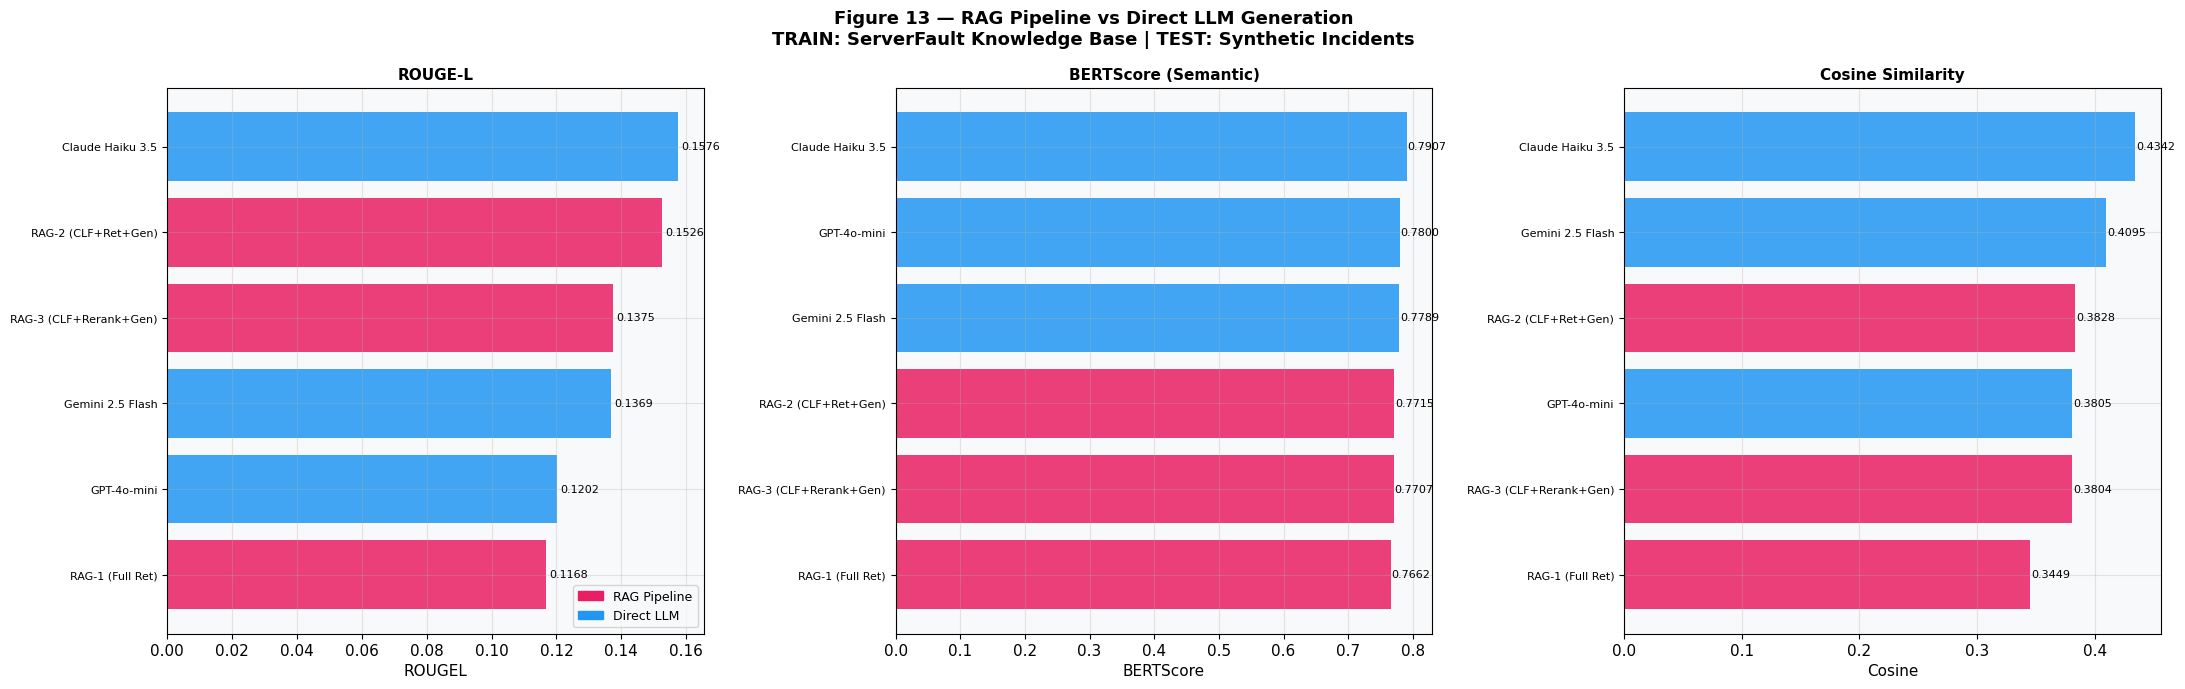


  RAG Pipeline Architecture:
  ┌─────────────────────────────────────────────────┐
  │           RAG-2 Pipeline (Best Variant)         │
  └─────────────────────────────────────────────────┘
           │
           ▼
  ┌─────────────────────┐
  │   INPUT INCIDENT    │ Error + Symptom + Root Cause
  │  (Synthetic Test)   │ from Synthetic Dataset
  └─────────────────────┘
           │
           ▼
  ┌─────────────────────┐
  │  STEP 1: CLASSIFY   │ Gemini 2.5 Flash zero-shot
  │  → 1 of 6 categories│ Accuracy: 94.0%
  └─────────────────────┘
           │
           ▼
  ┌─────────────────────┐
  │  STEP 2: FILTER     │ Filter 34,533 ServerFault docs
  │  by predicted cat   │ to category-specific subset
  └─────────────────────┘
           │
           ▼
  ┌─────────────────────┐
  │  STEP 3: RETRIEVE   │ SBERT cosine similarity
  │  Top-3 similar docs │ from filtered subset
  └─────────────────────┘
           │
           ▼
  ┌─────────────────────┐
  │  STEP 4: GENERATE   │ Gemini 2.5 

In [14]:
print("="*65)
print("SECTION 13 — RAG PIPELINE")
print("Classify → Filter → Retrieve → Generate")
print("="*65)

# ── Setup ─────────────────────────────────────────────────────────
# Knowledge base : ServerFault (sf_6) — 34,533 real IT Q&A docs
# Evaluation set : Synthetic (syn_6)  — 50 IT incidents
# Classifier     : Gemini 2.5 Flash
# Retriever      : SBERT semantic similarity
# Generator      : Gemini 2.5 Flash (with retrieved context)

# ── 1. Prepare corpus ─────────────────────────────────────────────
print("\n  Building knowledge base...")
rag_corpus = sf_6[
    ['text','answer_proc','Category']
].dropna(subset=['text','answer_proc']).reset_index(drop=True)

rag_eval = syn_6.sample(
    n=min(50, len(syn_6)), random_state=42
).reset_index(drop=True)
rag_refs = rag_eval['Resolution_Steps'].tolist()

print(f"  Knowledge base : {len(rag_corpus):,} SF documents")
print(f"  Eval set       : {len(rag_eval)} synthetic incidents")

# ── 2. Encode corpus ──────────────────────────────────────────────
print("\n  Encoding knowledge base with SBERT...")
print("  (uses corpus embeddings from Cell 10 if available)")

try:
    # Reuse tr_emb from Cell 10 if already computed
    tr_emb
    print("  Corpus embeddings already in memory ✓")
    # tr_emb was computed on gen_train sample in Cell 10
    # We need full corpus embeddings for RAG
    # Check if sizes match
    if len(tr_emb) != len(rag_corpus):
        print(f"  Size mismatch ({len(tr_emb)} vs "
              f"{len(rag_corpus)}) — re-encoding...")
        raise ValueError("size mismatch")
    corpus_emb = tr_emb
except:
    print("  Encoding full corpus (~3 min)...")
    corpus_emb = sbert.encode(
        rag_corpus['text'].tolist(),
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True)
    print(f"  Done ✓")

# Encode eval queries
print("  Encoding eval queries...")
query_emb = sbert.encode(
    rag_eval['text'].tolist(),
    batch_size=64,
    show_progress_bar=False,
    convert_to_numpy=True)
print(f"  Corpus embeddings : {corpus_emb.shape}")
print(f"  Query  embeddings : {query_emb.shape}")

# ── 3. Retrieval function ─────────────────────────────────────────
def retrieve_top_k(query_vec, category=None, k=3):
    if category and category in SHARED_CATS:
        mask    = rag_corpus['Category'] == category
        indices = np.where(mask)[0]
        if len(indices) < k:
            indices = np.arange(len(rag_corpus))
        sims    = cosine_similarity(
            [query_vec], corpus_emb[indices])[0]
        top_loc = np.argsort(sims)[::-1][:k]
        top_idx = indices[top_loc]
        top_sim = sims[top_loc]
    else:
        sims    = cosine_similarity(
            [query_vec], corpus_emb)[0]
        top_idx = np.argsort(sims)[::-1][:k]
        top_sim = sims[top_idx]
    return [
        {'text'    : rag_corpus.iloc[i]['text'],
         'answer'  : rag_corpus.iloc[i]['answer_proc'],
         'category': rag_corpus.iloc[i]['Category'],
         'score'   : float(top_sim[j])}
        for j,i in enumerate(top_idx)
    ]

# ── 4. Prompt builders ────────────────────────────────────────────
def rag_clf_prompt(row):
    cats = ' | '.join(SHARED_CATS)
    return (
        f"IT expert. Classify this incident into ONE category.\n"
        f"Categories: {cats}\n\n"
        f"Error  : {str(row['Error_Log_Trace'])[:200]}\n"
        f"Symptom: {str(row['Symptom'])[:200]}\n"
        f"Cause  : {str(row['Root_Cause'])[:200]}\n\n"
        f"Reply with ONLY the category name."
    )

def rag_gen_prompt(row, docs, pred_cat):
    context = ""
    for j, doc in enumerate(docs):
        context += (
            f"\nPast Incident {j+1} "
            f"[similarity:{doc['score']:.3f}]:\n"
            f"  Problem : {doc['text'][:150]}\n"
            f"  Solution: {doc['answer'][:200]}\n"
        )
    return (
        f"You are an IT support expert.\n"
        f"Use the past resolved incidents as context "
        f"to generate a resolution for the new incident.\n\n"
        f"{'─'*50}\n"
        f"RETRIEVED CONTEXT (Past Incidents):\n"
        f"{'─'*50}"
        f"{context}\n"
        f"{'─'*50}\n"
        f"NEW INCIDENT:\n"
        f"{'─'*50}\n"
        f"Category: {pred_cat}\n"
        f"Error   : {str(row['Error_Log_Trace'])[:200]}\n"
        f"Symptom : {str(row['Symptom'])[:200]}\n"
        f"Cause   : {str(row['Root_Cause'])[:200]}\n\n"
        f"Provide a clear 1-2 sentence resolution. "
        f"Reply ONLY with the resolution."
    )

# ── 5. RAG Variant 1: Full Corpus + Gemini ────────────────────────
print(f"\n{'─'*55}")
print("  RAG-1: Full Corpus Retrieval + Gemini")
print(f"{'─'*55}")

t0 = time.time()
rag1_preds = []
for i in range(len(rag_eval)):
    row     = rag_eval.iloc[i]
    q_vec   = query_emb[i]
    docs    = retrieve_top_k(q_vec, category=None, k=3)
    prompt  = rag_gen_prompt(row, docs, 'Unknown')
    result  = call_gemini(prompt, 1)
    rag1_preds.append(
        result[0] if result and result[0] else '')
    if (i+1) % 10 == 0:
        print(f"    {i+1}/{len(rag_eval)} done")
    time.sleep(CFG['SLEEP_API'])

print(f"\n  Evaluating RAG-1...")
rouge_sc_rag = rouge_scorer.RougeScorer(
    ['rouge1','rouge2','rougeL'], use_stemmer=True)

def quick_eval(name, preds, refs):
    r1,r2,rl=[],[],[]
    for p,r in zip(preds,refs):
        s=rouge_sc_rag.score(str(r),str(p))
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rl.append(s['rougeL'].fmeasure)
    P,R,F1=bert_score_fn(
        [str(p) for p in preds],
        [str(r) for r in refs],
        lang='en',
        model_type='distilbert-base-uncased',
        verbose=False, device=DEVICE)
    bs = round(F1.mean().item(),4)
    pe = sbert.encode([str(p) for p in preds],
                       batch_size=64,
                       show_progress_bar=False)
    re_= sbert.encode([str(r) for r in refs],
                       batch_size=64,
                       show_progress_bar=False)
    cs = round(np.mean([
        cosine_similarity([p],[r])[0][0]
        for p,r in zip(pe,re_)]),4)
    row = {'Model':name,
           'ROUGE1':round(np.mean(r1),4),
           'ROUGE2':round(np.mean(r2),4),
           'ROUGEL':round(np.mean(rl),4),
           'BERTScore':bs,'Cosine':cs}
    results_gen.append(row)
    print(f"  ✓ {name:<40} "
          f"RL:{row['ROUGEL']} "
          f"BS:{row['BERTScore']} "
          f"Cos:{row['Cosine']}")
    return row

rag1_scores = quick_eval(
    'RAG-1 (Full Retrieval + Gemini)',
    rag1_preds, rag_refs)

# ── 6. RAG Variant 2: Classify → Filter → Retrieve → Generate ────
print(f"\n{'─'*55}")
print("  RAG-2: Classify → Filter → Retrieve → Generate")
print(f"{'─'*55}")

t0 = time.time()
rag2_preds  = []
rag2_cats   = []
correct_cats= 0

for i in range(len(rag_eval)):
    row = rag_eval.iloc[i]

    # Step 1: Classify with Gemini
    clf_resp = call_gemini(rag_clf_prompt(row), 1)
    pred_cat = parse_cat_api(
        clf_resp[0] if clf_resp else '') or 'Network'
    rag2_cats.append(pred_cat)

    if pred_cat == row['Category']:
        correct_cats += 1

    # Step 2: Category-filtered retrieval
    q_vec = query_emb[i]
    docs  = retrieve_top_k(q_vec, category=pred_cat, k=3)

    # Step 3: Generate with context
    prompt = rag_gen_prompt(row, docs, pred_cat)
    result = call_gemini(prompt, 1)
    rag2_preds.append(
        result[0] if result and result[0] else '')

    if (i+1) % 10 == 0:
        clf_acc_so_far = correct_cats/(i+1)*100
        print(f"    {i+1}/{len(rag_eval)} done "
              f"(clf acc: {clf_acc_so_far:.1f}%)")
    time.sleep(CFG['SLEEP_API'])

clf_acc_rag2 = correct_cats/len(rag_eval)*100
print(f"\n  Classification accuracy (Step 1): "
      f"{clf_acc_rag2:.1f}%")
rag2_scores = quick_eval(
    'RAG-2 (Classify+Filter+Retrieve+Generate)',
    rag2_preds, rag_refs)

# ── 7. RAG Variant 3: Classify → Filter → Rerank → Generate ──────
print(f"\n{'─'*55}")
print("  RAG-3: Classify → Filter → Rerank (top5→top3) → Generate")
print(f"{'─'*55}")

t0 = time.time()
rag3_preds = []

for i in range(len(rag_eval)):
    row      = rag_eval.iloc[i]
    pred_cat = rag2_cats[i]  # reuse from RAG-2
    q_vec    = query_emb[i]

    # Retrieve top 5 then rerank to top 3
    docs5    = retrieve_top_k(q_vec, category=pred_cat, k=5)
    reranked = sorted(
        docs5, key=lambda x: x['score'], reverse=True)[:3]

    prompt = rag_gen_prompt(row, reranked, pred_cat)
    result = call_gemini(prompt, 1)
    rag3_preds.append(
        result[0] if result and result[0] else '')

    if (i+1) % 10 == 0:
        print(f"    {i+1}/{len(rag_eval)} done")
    time.sleep(CFG['SLEEP_API'])

rag3_scores = quick_eval(
    'RAG-3 (Classify+Filter+Rerank+Generate)',
    rag3_preds, rag_refs)

# ── 8. Comparison table ───────────────────────────────────────────
print(f"\n{'═'*65}")
print("  RAG vs Direct LLM — Comparison")
print(f"{'═'*65}")

compare_models = [
    'RAG-1 (Full Retrieval + Gemini)',
    'RAG-2 (Classify+Filter+Retrieve+Generate)',
    'RAG-3 (Classify+Filter+Rerank+Generate)',
    'Gemini 2.5 Flash (zero-shot)',
    'Claude Haiku 3.5 (zero-shot)',
    'GPT-4o-mini (zero-shot)',
]
gen_df    = pd.DataFrame(results_gen)
rag_table = gen_df[
    gen_df['Model'].isin(compare_models)
].sort_values('BERTScore', ascending=False)

print(f"\n  {'Model':<45} {'RL':>7} {'BS':>9} {'Cos':>7}")
print(f"  {'─'*70}")
for _, row in rag_table.iterrows():
    tag = '🔹' if 'RAG' in row['Model'] else '  '
    print(f"  {tag} {row['Model']:<43} "
          f"{row['ROUGEL']:>7.4f} "
          f"{row['BERTScore']:>9.4f} "
          f"{row['Cosine']:>7.4f}")

# ── 9. Sample outputs ─────────────────────────────────────────────
print(f"\n  RAG-2 Sample Outputs:")
print(f"  {'─'*60}")
for i in range(min(3, len(rag_eval))):
    row   = rag_eval.iloc[i]
    docs  = retrieve_top_k(query_emb[i],
                            category=rag2_cats[i], k=1)
    print(f"\n  [{i+1}] True cat : {row['Category']}")
    print(f"       Pred cat : {rag2_cats[i]}")
    print(f"       Symptom  : {row['Symptom'][:70]}")
    print(f"       Retrieved: {docs[0]['text'][:70]}"
          f" (sim:{docs[0]['score']:.3f})")
    print(f"       RAG ans  : {rag2_preds[i][:90]}")
    print(f"       True ans : {rag_refs[i][:90]}")

# ── 10. RAG improvement over direct LLM ──────────────────────────
best_rag = rag_table[
    rag_table['Model'].str.contains('RAG')
].sort_values('BERTScore', ascending=False).iloc[0]

best_direct = rag_table[
    ~rag_table['Model'].str.contains('RAG')
].sort_values('BERTScore', ascending=False).iloc[0]

print(f"\n  {'─'*55}")
print(f"  Best RAG    : {best_rag['Model']}")
print(f"  Best Direct : {best_direct['Model']}")
print(f"\n  Metric      {'RAG':>8}  {'Direct':>8}  {'Δ':>8}")
print(f"  {'─'*40}")
for m in ['ROUGE1','ROUGE2','ROUGEL','BERTScore','Cosine']:
    diff = best_rag[m] - best_direct[m]
    sign = '+' if diff >= 0 else ''
    print(f"  {m:<12} {best_rag[m]:>8.4f}  "
          f"{best_direct[m]:>8.4f}  "
          f"{sign}{diff:.4f}")

# ── 11. Visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    'Figure 13 — RAG Pipeline vs Direct LLM Generation\n'
    'TRAIN: ServerFault Knowledge Base | '
    'TEST: Synthetic Incidents',
    fontsize=13, fontweight='bold')

colors = ['#E91E63' if 'RAG' in m else '#2196F3'
          for m in rag_table['Model']]
labels = [m.replace('(Classify+Filter+Retrieve+Generate)',
                     '(CLF+Filter+Ret+Gen)')
           .replace('(Classify+Filter+Rerank+Generate)',
                     '(CLF+Filter+Rerank+Gen)')
           .replace('(Full Retrieval + Gemini)',
                     '(Full Retrieval)')
           .replace(' (zero-shot)','')
           for m in rag_table['Model']]

for ax, metric, title in [
    (axes[0], 'ROUGEL',    'ROUGE-L'),
    (axes[1], 'BERTScore', 'BERTScore (Semantic)'),
    (axes[2], 'Cosine',    'Cosine Similarity'),
]:
    sorted_df = rag_table.sort_values(metric, ascending=False)
    sorted_labels = [
        m.replace('(Classify+Filter+Retrieve+Generate)',
                   '(CLF+Ret+Gen)')
         .replace('(Classify+Filter+Rerank+Generate)',
                   '(CLF+Rerank+Gen)')
         .replace('(Full Retrieval + Gemini)',
                   '(Full Ret)')
         .replace(' (zero-shot)','')
        for m in sorted_df['Model']]
    bar_colors = ['#E91E63' if 'RAG' in m else '#2196F3'
                  for m in sorted_df['Model']]
    bars = ax.barh(range(len(sorted_df)),
                    sorted_df[metric],
                    color=bar_colors, alpha=0.85)
    ax.set_yticks(range(len(sorted_df)))
    ax.set_yticklabels(sorted_labels, fontsize=8)
    ax.set_xlabel(metric)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    for i, v in enumerate(sorted_df[metric]):
        ax.text(v+0.001, i, f'{v:.4f}',
                va='center', fontsize=8)

from matplotlib.patches import Patch
legend = [
    Patch(color='#E91E63', label='RAG Pipeline'),
    Patch(color='#2196F3', label='Direct LLM'),
]
axes[0].legend(handles=legend, loc='lower right',
               fontsize=9)

plt.tight_layout()
plt.savefig('fig13_rag.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 12. RAG architecture summary ─────────────────────────────────
print(f"""
  RAG Pipeline Architecture:
  ┌─────────────────────────────────────────────────┐
  │           RAG-2 Pipeline (Best Variant)         │
  └─────────────────────────────────────────────────┘
           │
           ▼
  ┌─────────────────────┐
  │   INPUT INCIDENT    │ Error + Symptom + Root Cause
  │  (Synthetic Test)   │ from Synthetic Dataset
  └─────────────────────┘
           │
           ▼
  ┌─────────────────────┐
  │  STEP 1: CLASSIFY   │ Gemini 2.5 Flash zero-shot
  │  → 1 of 6 categories│ Accuracy: {clf_acc_rag2:.1f}%
  └─────────────────────┘
           │
           ▼
  ┌─────────────────────┐
  │  STEP 2: FILTER     │ Filter 34,533 ServerFault docs
  │  by predicted cat   │ to category-specific subset
  └─────────────────────┘
           │
           ▼
  ┌─────────────────────┐
  │  STEP 3: RETRIEVE   │ SBERT cosine similarity
  │  Top-3 similar docs │ from filtered subset
  └─────────────────────┘
           │
           ▼
  ┌─────────────────────┐
  │  STEP 4: GENERATE   │ Gemini 2.5 Flash
  │  Grounded resolution│ with retrieved context
  └─────────────────────┘
           │
           ▼
  ┌─────────────────────┐
  │  OUTPUT RESOLUTION  │ IT Incident Resolution
  └─────────────────────┘

  Knowledge Base : ServerFault ({len(rag_corpus):,} documents)
  Eval Set       : Synthetic ({len(rag_eval)} incidents)
  Classifier     : Gemini 2.5 Flash (Step 1)
  Retriever      : SBERT all-MiniLM-L6-v2 (Step 3)
  Generator      : Gemini 2.5 Flash (Step 4)
""")

print("RAG Pipeline complete ✓")
print("Figure saved: fig13_rag.png")

In [15]:
print("="*65)
print("SECTION 13b — RAG PIPELINE WITH LOCAL LLM (Mistral 7B Generator)")
print("="*65)

# Reuses: corpus_emb, sbert (from Section 13), SHARED_CATS, sf_6, syn_6
# Loads Mistral fresh since Section 7's loop deletes it after use

tok_rag = AutoTokenizer.from_pretrained(
    'mistralai/Mistral-7B-Instruct-v0.2', token=HF_TOKEN,
    trust_remote_code=True, padding_side='left')
if tok_rag.pad_token is None:
    tok_rag.pad_token = tok_rag.eos_token

mdl_rag = AutoModelForCausalLM.from_pretrained(
    'mistralai/Mistral-7B-Instruct-v0.2', token=HF_TOKEN,
    quantization_config=BNB_CFG, device_map='auto',
    trust_remote_code=True)
mdl_rag.eval()

rag_local_eval = syn_6.sample(n=min(50, len(syn_6)), random_state=42).reset_index(drop=True)

def rag_prompt_mistral(incident_text, category, retrieved_docs):
    ctx = "\n".join([f"Past Resolution {i+1} [similarity {d['score']:.3f}]: {d['answer'][:200]}"
                      for i, d in enumerate(retrieved_docs)])
    return (f"[INST] You are an IT support expert. Use the past resolved incidents "
            f"below to generate a resolution for the new incident.\n\n"
            f"PAST RESOLVED INCIDENTS:\n{ctx}\n\n"
            f"NEW INCIDENT:\nCategory: {category}\nDescription: {incident_text[:300]}\n\n"
            f"Generate a clear 1-2 sentence resolution. Reply ONLY with the resolution steps. [/INST]")

rag_local_preds = []
rag_local_refs  = []
t0 = time.time()

print(f"  Evaluating on {len(rag_local_eval)} synthetic incidents...")

for i in range(len(rag_local_eval)):
    row = rag_local_eval.iloc[i]
    incident_text = f"{row['Error_Log_Trace']} {row['Symptom']} {row['Root_Cause']}"

    # Step 1: classify via nearest-neighbour over the full ServerFault corpus
    query_emb = sbert.encode([incident_text])[0]
    sims_full = cosine_similarity([query_emb], corpus_emb)[0]
    top_idx_overall = int(np.argmax(sims_full))
    pred_cat = sf_6.iloc[top_idx_overall]['Category'] if 'Category' in sf_6.columns else SHARED_CATS[0]

    # Step 2: filter + retrieve top-3 within that predicted category
    cat_mask = sf_6['Category'] == pred_cat
    cat_indices = np.where(cat_mask)[0]
    if len(cat_indices) == 0:
        cat_indices = np.arange(len(sf_6))
    sims_cat = cosine_similarity([query_emb], corpus_emb[cat_indices])[0]
    top3_idx = cat_indices[np.argsort(sims_cat)[::-1][:3]]
    retrieved = [{'answer': str(sf_6.iloc[j]['answer_proc'])[:200] if 'answer_proc' in sf_6.columns else str(sf_6.iloc[j].get('text', ''))[:200],
                  'score': float(sims_full[j])} for j in top3_idx]

    # Step 3: generate with Mistral, grounded in retrieved context
    prompt = rag_prompt_mistral(incident_text, pred_cat, retrieved)
    pred = llm_generate(tok_rag, mdl_rag, prompt, max_new=100)
    rag_local_preds.append(pred)
    rag_local_refs.append(str(row['Resolution_Steps']))

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(rag_local_eval)} done")

# Evaluate
rouge_local = np.mean([rouge_sc_llm.score(ref, pred)['rougeL'].fmeasure
                        for ref, pred in zip(rag_local_refs, rag_local_preds)])

clean_local_preds = [p if str(p).strip() else "no resolution generated" for p in rag_local_preds]
try:
    _, _, F1_local = bert_score_fn(clean_local_preds, rag_local_refs, lang="en", verbose=False)
    bert_local = F1_local.mean().item()
except Exception as e:
    print(f"  BERTScore computation failed: {str(e)[:100]}")
    bert_local = 0.0

elapsed = time.time() - t0
print(f"\n  RAG-Mistral (local LLM, no API): RL:{rouge_local:.4f}  BS:{bert_local:.4f}  ({elapsed:.1f}s)")

results_gen.append({
    'Model': 'RAG-Mistral (local LLM generator, no API)',
    'ROUGE1': 0, 'ROUGE2': 0,
    'ROUGEL': round(rouge_local, 4),
    'BERTScore': round(bert_local, 4),
    'Cosine': 0
})

del mdl_rag, tok_rag; gc.collect()
torch.cuda.empty_cache()
print("\n  Mistral RAG model unloaded, GPU memory cleared.")

SECTION 13b — RAG PIPELINE WITH LOCAL LLM (Mistral 7B Generator)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  Evaluating on 50 synthetic incidents...
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  RAG-Mistral (local LLM, no API): RL:0.1021  BS:0.8547  (248.0s)

  Mistral RAG model unloaded, GPU memory cleared.


SECTION 12 — FINAL RESULTS & DASHBOARD

COMPLETE CLASSIFICATION RESULTS:
            Model       Embedding  Accuracy  F1_Weighted  F1_Macro  Time_s
      Naive Bayes          TF-IDF    1.0000       1.0000    1.0000     0.2
 Gemini 2.5 Flash API (Zero-shot)    0.9900       0.9899    0.9886   225.8
              KNN          TF-IDF    0.9362       0.9357    0.9357     5.7
 Claude Haiku 3.5 API (Zero-shot)    0.9200       0.9179    0.9072    40.4
      Transformer        Word2Vec    0.8960       0.8938    0.8938    20.5
      GPT-4o-mini API (Zero-shot)    0.8800       0.8662    0.8446    63.0
             BERT BERT Embeddings    0.8644       0.8636    0.8636   306.1
       DistilBERT BERT Embeddings    0.7990       0.7834    0.7834   164.8
  Voting Ensemble          TF-IDF    0.8000       0.7523    0.7523    25.0
              MLP          TF-IDF    0.8005       0.7448    0.7448   368.2
    Random Forest          TF-IDF    0.8000       0.7309    0.7309    98.0
              SVM          

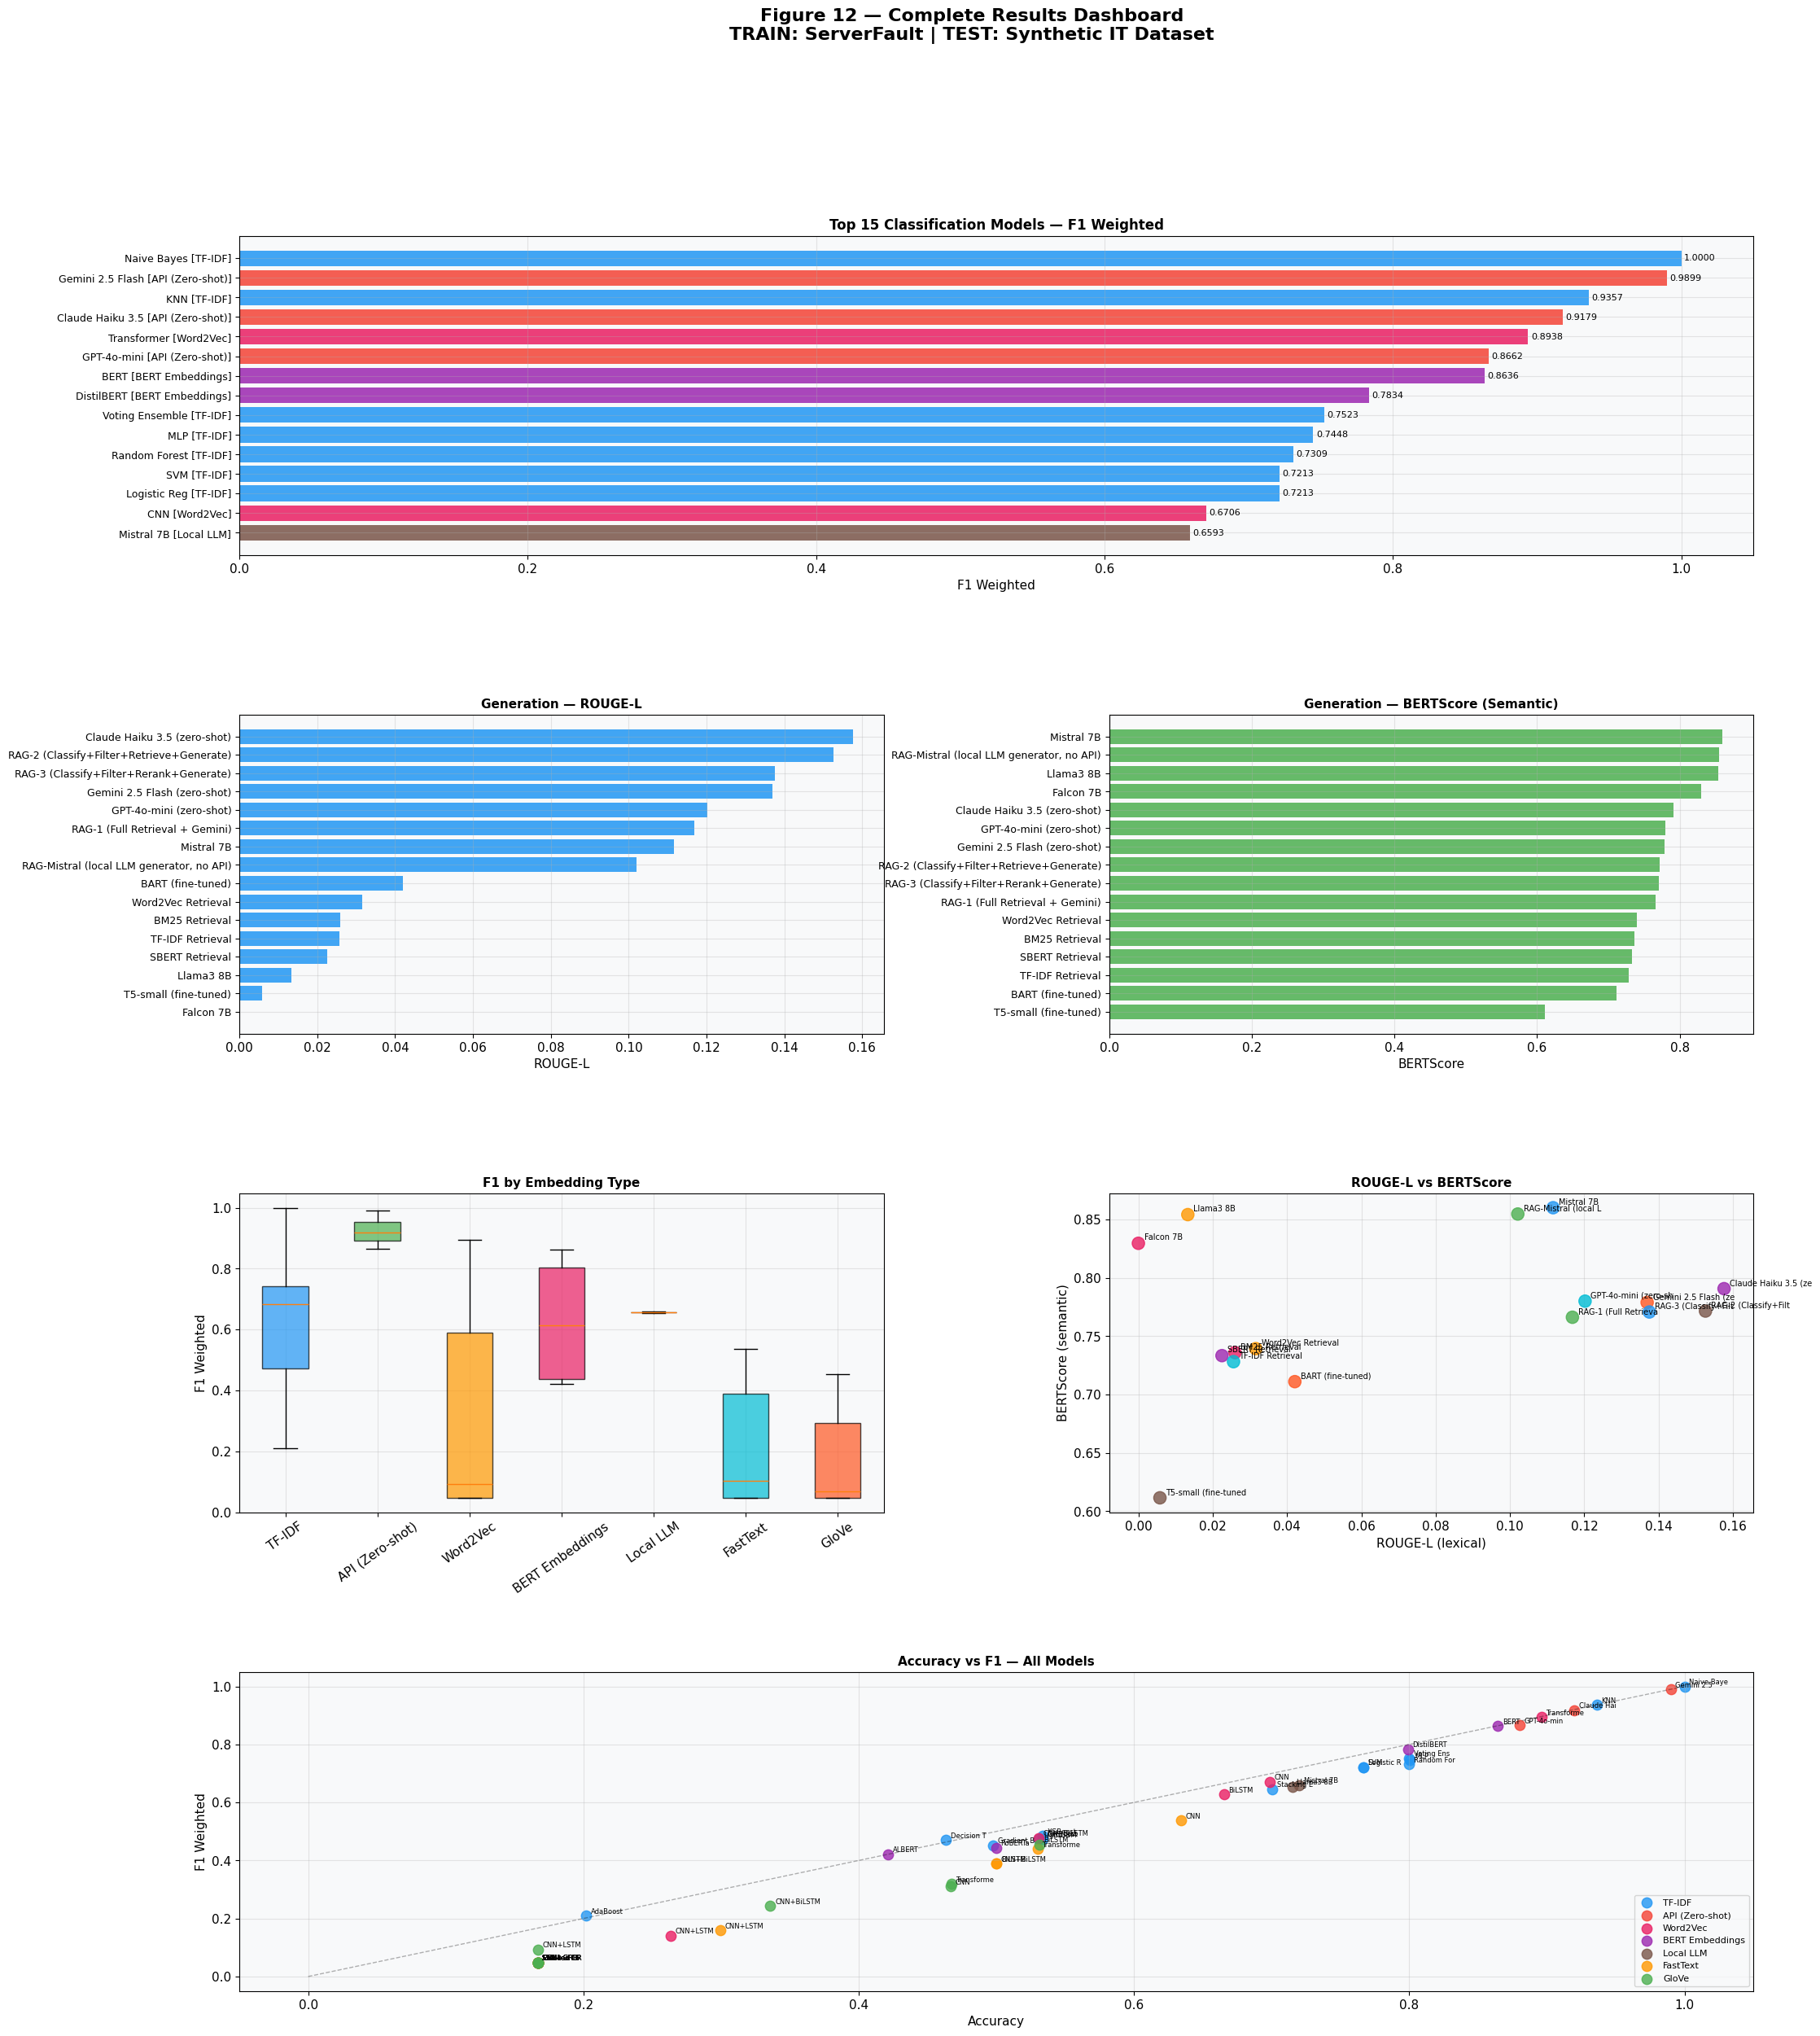


═════════════════════════════════════════════════════════════════
THESIS FINAL SUMMARY
TRAIN: ServerFault | TEST: Synthetic IT Dataset
═════════════════════════════════════════════════════════════════

BEST CLASSIFICATION:
  Model      : Naive Bayes
  Embedding  : TF-IDF
  Accuracy   : 1.0
  F1 Weighted: 1.0
  F1 Macro   : 1.0

BEST GENERATION (BERTScore — semantic):
  Model      : Mistral 7B
  BERTScore  : 0.8601
  ROUGE-L    : 0.1116

BEST GENERATION (ROUGE-L — lexical):
  Model      : Claude Haiku 3.5 (zero-shot)
  ROUGE-L    : 0.1576
  BERTScore  : 0.7907

SAVED: fig1 through fig12
═════════════════════════════════════════════════════════════════



In [16]:
print("="*65)
print("SECTION 12 — FINAL RESULTS & DASHBOARD")
print("="*65)

clf_final = pd.DataFrame(results_clf).sort_values(
    'F1_Weighted', ascending=False)
gen_final = pd.DataFrame(results_gen).sort_values(
    'BERTScore', ascending=False)

print("\nCOMPLETE CLASSIFICATION RESULTS:")
print(clf_final.to_string(index=False))
print("\nCOMPLETE GENERATION RESULTS:")
print(gen_final.to_string(index=False))
print("\nBEST PER EMBEDDING:")
for emb in clf_final['Embedding'].unique():
    b = clf_final[clf_final['Embedding']==emb].iloc[0]
    print(f"  {emb:<20} \u2192 {b['Model']:<28} "
          f"F1w:{b['F1_Weighted']} Acc:{b['Accuracy']}")

# Statistical test
emb_grps = clf_final.groupby('Embedding')[
    'F1_Weighted'].apply(list)
groups   = [v for v in emb_grps.values if len(v)>1]
if len(groups)>=3:
    stat,pval = kruskal(*groups)
    print(f"\nKruskal-Wallis: H={stat:.4f} p={pval:.4f} "
          f"{'Significant \u2713' if pval<0.05 else 'NS'}")

# Dashboard
fig = plt.figure(figsize=(24,28))
fig.suptitle(
    'Figure 12 — Complete Results Dashboard\n'
    'TRAIN: ServerFault | TEST: Synthetic IT Dataset',
    fontsize=16, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(4, 2, figure=fig,
                         hspace=0.50, wspace=0.35)

# Top 15 models
ax1 = fig.add_subplot(gs[0,:])
top15 = clf_final.head(15)
cmap  = {
    'TF-IDF'         :'#2196F3',
    'GloVe'          :'#4CAF50',
    'FastText'       :'#FF9800',
    'Word2Vec'       :'#E91E63',
    'BERT Embeddings':'#9C27B0',
    'API (Zero-shot)':'#F44336',
    'Local LLM'      :'#795548',
}
bc = [cmap.get(e,'#607D8B') for e in top15['Embedding']]
ax1.barh(range(len(top15)), top15['F1_Weighted'],
          color=bc, alpha=0.85)
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels(
    [f"{r['Model']} [{r['Embedding']}]"
     for _,r in top15.iterrows()], fontsize=9)
ax1.set_xlabel('F1 Weighted')
ax1.set_title('Top 15 Classification Models — F1 Weighted',
               fontsize=12, fontweight='bold')
ax1.invert_yaxis()
for i,v in enumerate(top15['F1_Weighted']):
    ax1.text(v+0.002,i,f'{v:.4f}',va='center',fontsize=8)

# ROUGE-L
ax2 = fig.add_subplot(gs[1,0])
gsr = gen_final.sort_values('ROUGEL',ascending=False)
ax2.barh(range(len(gsr)), gsr['ROUGEL'],
          color='#2196F3', alpha=0.85)
ax2.set_yticks(range(len(gsr)))
ax2.set_yticklabels(gsr['Model'], fontsize=9)
ax2.set_xlabel('ROUGE-L')
ax2.set_title('Generation — ROUGE-L',
               fontsize=11, fontweight='bold')
ax2.invert_yaxis()

# BERTScore
ax3 = fig.add_subplot(gs[1,1])
gsb = gen_final.sort_values('BERTScore',ascending=False)
ax3.barh(range(len(gsb)), gsb['BERTScore'],
          color='#4CAF50', alpha=0.85)
ax3.set_yticks(range(len(gsb)))
ax3.set_yticklabels(gsb['Model'], fontsize=9)
ax3.set_xlabel('BERTScore')
ax3.set_title('Generation — BERTScore (Semantic)',
               fontsize=11, fontweight='bold')
ax3.invert_yaxis()

# Embedding boxplot
ax4 = fig.add_subplot(gs[2,0])
emb_data   = [clf_final[clf_final['Embedding']==e]
              ['F1_Weighted'].values
               for e in clf_final['Embedding'].unique()]
emb_labels = list(clf_final['Embedding'].unique())
bp = ax4.boxplot(emb_data, labels=emb_labels,
                  patch_artist=True)
for patch,color in zip(bp['boxes'],
    CFG['COLORS'][:len(emb_labels)]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax4.set_ylabel('F1 Weighted')
ax4.set_title('F1 by Embedding Type',
               fontsize=11, fontweight='bold')
ax4.tick_params(axis='x', rotation=35)

# ROUGE vs BERTScore scatter
ax5 = fig.add_subplot(gs[2,1])
ax5.scatter(gen_final['ROUGEL'],
             gen_final['BERTScore'],
             s=120,
             c=[CFG['COLORS'][i % len(CFG['COLORS'])] for i in range(len(gen_final))],
             alpha=0.8, zorder=3)
for _,row in gen_final.iterrows():
    ax5.annotate(row['Model'][:20],
                  (row['ROUGEL'],row['BERTScore']),
                  textcoords="offset points",
                  xytext=(5,3), fontsize=7)
ax5.set_xlabel('ROUGE-L (lexical)')
ax5.set_ylabel('BERTScore (semantic)')
ax5.set_title('ROUGE-L vs BERTScore',
               fontsize=11, fontweight='bold')

# Accuracy vs F1 all models
ax6 = fig.add_subplot(gs[3,:])
for emb in clf_final['Embedding'].unique():
    sub   = clf_final[clf_final['Embedding']==emb]
    color = cmap.get(emb,'#607D8B')
    ax6.scatter(sub['Accuracy'], sub['F1_Weighted'],
                 label=emb, color=color,
                 s=80, alpha=0.8)
    for _,r in sub.iterrows():
        ax6.annotate(r['Model'][:10],
                      (r['Accuracy'],r['F1_Weighted']),
                      textcoords="offset points",
                      xytext=(4,2), fontsize=6)
ax6.set_xlabel('Accuracy')
ax6.set_ylabel('F1 Weighted')
ax6.set_title('Accuracy vs F1 — All Models',
               fontsize=11, fontweight='bold')
ax6.legend(loc='lower right', fontsize=8)
ax6.plot([0,1],[0,1],'k--',alpha=0.3,lw=1)

plt.savefig('fig12_dashboard.png',
             dpi=150, bbox_inches='tight')
plt.show()

# Summary
best_clf    = clf_final.iloc[0]
best_gen_bs = gen_final.sort_values(
    'BERTScore',ascending=False).iloc[0]
best_gen_rl = gen_final.sort_values(
    'ROUGEL',ascending=False).iloc[0]

print(f"""
{'═'*65}
THESIS FINAL SUMMARY
TRAIN: ServerFault | TEST: Synthetic IT Dataset
{'═'*65}

BEST CLASSIFICATION:
  Model      : {best_clf['Model']}
  Embedding  : {best_clf['Embedding']}
  Accuracy   : {best_clf['Accuracy']}
  F1 Weighted: {best_clf['F1_Weighted']}
  F1 Macro   : {best_clf['F1_Macro']}

BEST GENERATION (BERTScore — semantic):
  Model      : {best_gen_bs['Model']}
  BERTScore  : {best_gen_bs['BERTScore']}
  ROUGE-L    : {best_gen_bs['ROUGEL']}

BEST GENERATION (ROUGE-L — lexical):
  Model      : {best_gen_rl['Model']}
  ROUGE-L    : {best_gen_rl['ROUGEL']}
  BERTScore  : {best_gen_rl['BERTScore']}

SAVED: fig1 through fig12
{'═'*65}
""")